# PEI National Park — Fire Weather Index Network Analysis

**Client:** Parks Canada Agency, PEI Field Unit
**Audience:** Field unit managers, fire-program leads, and the technical team supporting the FWI dashboard.
**Scope:** Three-year hourly record (2023-04-01 → 2026-03-23) across six weather stations in PEI National Park.

---

## Executive Summary

**What this report does.** It (1) inventories the weather data feeding the Fire Weather Index (FWI) dashboard, (2) measures how much of that data is real versus reconstructed, and (3) recommends which stations are essential versus candidates for consolidation.

**Headline findings**

> **Network is computable end-to-end.** All six stations produce a complete FWI chain (FFMC → DMC → DC → ISI → BUI → FWI) on every analysis day after pipeline processing.
>
> **Two stations rely heavily on imputed humidity.** Stanley Bridge and Tracadie are missing ~100% of their relative-humidity (RH) values pre-imputation. Post-imputation, the pipeline fills ~83% of Stanley Bridge RH and ~87% of Tracadie RH using neighbouring stations. FWI values at those two sites should be treated as **network-blended estimates**, not independent measurements.
>
> **Greenwich and Stanhope have the most FWI chain breaks** (42 and 44 respectively), almost all caused by missing RH.
>
> **Temperature redundancy is high, but only on temperature.** PCA on hourly temperature shows 96% of the variance is a single shared signal across all six stations. The same analysis on RH, wind, and precipitation tells a very different story: PC1 explains 79%, 71%, and 55% of variance respectively, and **0 of 60 station pairs are confidently redundant on any non-temperature variable** at the 95%-bootstrap-CI level.
>
> **Removal recommendation: keep all six stations.** No station passes the bar for confident decommissioning once multivariate redundancy, leave-one-out (LOO) donor impact, partial correlation, and extreme-event behaviour are folded in. Specifically:
> - **Cavendish must be kept** — it is the largest single donor in the cross-station imputation network. Removing it would degrade ~38,600 downstream FWI rows at Stanley Bridge and Tracadie by up to 3.57 FWI points.
> - **Greenwich must be kept** — partial correlation (controlling for Stanhope) collapses Greenwich's apparent agreement with every other station from ~0.91 to 0.26–0.41. It is the most uniquely-sited station in the network.
> - **Stanhope must be kept** — reference station; only station with complete observed records for all four FWI core inputs.
> - **North Rustico, Stanley Bridge, and Tracadie** are *deferred* pending field assessment. Stanley Bridge and Tracadie are the only operationally plausible decommission candidates (net receivers in the imputation network), but both already produce mostly-synthetic RH and removing either would shift more imputation load onto the remaining stations.

**Important caveats**

1. **The cross-station imputation network is load-bearing.** Decommissioning Stanley Bridge or Tracadie deletes the small share of *real* RH observations they currently produce; decommissioning Cavendish or North Rustico breaks the imputation that keeps Stanley Bridge and Tracadie computable. Read §7.5 before acting.
2. **Out-of-range counts are zero post-enforcement.** This is the expected state after the pipeline's quality-enforcement pass — not a sign of perfect upstream data.
3. **The Stanhope reference window is shorter** (ends 2025-12-31) than the comparison stations.

**How to read the rest of this report.** §2 is data inventory. §3 is the FWI itself. §4 is data-quality detail. §5–§7 set up the redundancy analysis on temperature. **§7.5 folds in the other three FWI inputs, leave-one-out donor impact, partial correlation, and extreme-event behaviour — it drives §9.4.** §8 is the temperature-divergence uncertainty bound. §9 is the synthesis. The [Extended Redundancy Report](redundancy_extended.html) (linked from the project landing page) carries the full evidence for §7.5.


## Glossary & Legend

### Fire Weather Index codes

The Canadian FWI system is a chain of six values. Each one builds on the previous and reacts to a different aspect of fuel moisture or fire spread.

| Code | Name | What it measures | Reacts to |
|---|---|---|---|
| **FFMC** | Fine Fuel Moisture Code | Moisture in surface litter (needles, grass) | Recent hours of temperature, RH, wind, rain |
| **DMC** | Duff Moisture Code | Moisture in loosely-compacted organic layer | Multi-day weather |
| **DC** | Drought Code | Moisture in deep, compact organic layer | Long-term drying |
| **ISI** | Initial Spread Index | Expected rate of fire spread | FFMC + wind |
| **BUI** | Buildup Index | Total fuel available to burn | DMC + DC |
| **FWI** | Fire Weather Index | Overall fire intensity potential | ISI + BUI |

Higher values = greater fire danger. The FWI scale is open-ended but Canadian forest agencies typically treat FWI > 20 as high and > 30 as extreme.

### Quality flags (`qf`)

Every cleaned weather value in this report carries a quality flag that records how it was obtained:

| `qf` | Meaning | Use with |
|---|---|---|
| **0** | Observed value, passed QA/QC | High confidence |
| **1** | Synthetic — imputed from same station's neighbours in time, or from cross-station fill | Treat as estimate |
| **9** | Chain-break gap-fill — fallback used when no donor was available and the FWI chain could not be advanced from observed data | Use with caution; check Section 3.4 |

In charts that follow:
- **Yellow background bands** flag days where at least one FWI input was `qf == 1` (synthetic).
- **Red background bands** flag days where at least one FWI input was `qf == 9` (chain-break fallback).


In [1]:
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from pathlib import Path
from sklearn.decomposition import PCA

from pea_met_network.qa_qc import coverage_summary
from pea_met_network.redundancy import (
    benchmark_to_stanhope,
    build_station_matrix,
    build_station_recommendations,
    cluster_station_order,
    pairwise_station_correlation,
    pca_station_loadings,
)

# ---------------------------------------------------------------------------
# FWI mode selector — switch between "hourly" and "compliant"
# ---------------------------------------------------------------------------
FWI_MODE = "hourly"

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path(".").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "notebooks" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Date range for analysis — must match cleaning-config.json
ANALYSIS_START = pd.Timestamp("2023-04-01", tz="UTC")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

print(f"FWI mode: {FWI_MODE}")
print(f"Processed dir: {PROCESSED_DIR}")


FWI mode: hourly


## 1. Data Loading

Load hourly processed data for all stations. Station list is derived from disk.

In [2]:
# Discover stations from disk — no hardcoded list
stations = sorted([
    d.name for d in PROCESSED_DIR.iterdir()
    if d.is_dir() and (d / "station_hourly.csv").exists()
])
print(f"Stations found: {stations}")

hourly_frames = []
daily_frames = []
for station in stations:
    h_path = PROCESSED_DIR / station / "station_hourly.csv"
    d_path = PROCESSED_DIR / station / "station_daily.csv"
    h_df = pd.read_csv(h_path, parse_dates=["timestamp_utc"])
    h_df["timestamp_utc"] = pd.to_datetime(h_df["timestamp_utc"], utc=True)
    h_df = h_df[h_df["timestamp_utc"] >= ANALYSIS_START]
    hourly_frames.append(h_df)
    if d_path.exists():
        d_df = pd.read_csv(d_path, parse_dates=["timestamp_utc"])
        d_df["timestamp_utc"] = pd.to_datetime(d_df["timestamp_utc"], utc=True)
        daily_frames.append(d_df)
    tmin = h_df["timestamp_utc"].min()
    tmax = h_df["timestamp_utc"].max()
    print(f"  {station}: {len(h_df)} hourly rows  ({tmin} to {tmax})")

hourly_all = pd.concat(hourly_frames, ignore_index=True)
if daily_frames:
    daily_all = pd.concat(daily_frames, ignore_index=True)
else:
    daily_all = pd.DataFrame()
n = hourly_all["station"].nunique()
print(f"\nCombined: {len(hourly_all)} hourly rows, {n} stations")


Stations found: ['cavendish', 'greenwich', 'north_rustico', 'stanhope', 'stanley_bridge', 'tracadie']
  cavendish: 26092 hourly rows  (2023-04-01 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)


  greenwich: 26092 hourly rows  (2023-04-01 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)
  north_rustico: 26113 hourly rows  (2023-04-01 00:00:00+00:00 to 2026-03-24 00:00:00+00:00)


  stanhope: 24144 hourly rows  (2023-04-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00)
  stanley_bridge: 26092 hourly rows  (2023-04-01 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)


  tracadie: 23956 hourly rows  (2023-06-29 00:00:00+00:00 to 2026-03-23 03:00:00+00:00)

Combined: 152489 hourly rows, 6 stations


## 2. Exploratory Data Analysis

### 2.1 Temporal Coverage

Date range, total hourly rows, and duration per station. Bars show each station's observation window; red bars are shorter than the full analysis window.


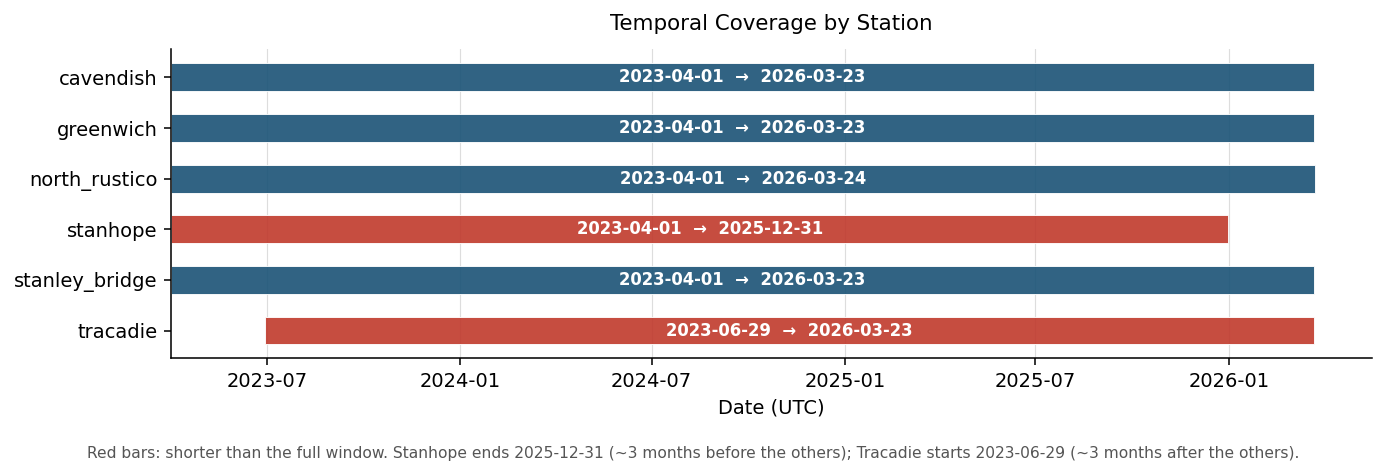

In [ ]:
# --- Temporal coverage: per-station date range, duration, hourly rows ---
import matplotlib.dates as mdates

rows = []
for station in stations:
    h_df = hourly_all[hourly_all["station"] == station]
    if h_df.empty:
        continue
    start = h_df["timestamp_utc"].min()
    end = h_df["timestamp_utc"].max()
    rows.append({
        "station": station,
        "first_obs": start.strftime("%Y-%m-%d"),
        "last_obs": end.strftime("%Y-%m-%d"),
        "duration_days": (end - start).days,
        "hourly_rows": len(h_df),
    })
coverage_table = pd.DataFrame(rows).sort_values("station").reset_index(drop=True)
print(coverage_table.to_string(index=False))

# Gantt-style timeline — one bar per station
analysis_start = coverage_table["first_obs"].pipe(pd.to_datetime).min()
analysis_end = coverage_table["last_obs"].pipe(pd.to_datetime).max()

fig, ax = plt.subplots(figsize=(10, 3.2))
for i, r in coverage_table.iterrows():
    s = pd.to_datetime(r["first_obs"])
    e = pd.to_datetime(r["last_obs"])
    is_short = (s > analysis_start) or (e < analysis_end - pd.Timedelta(days=1))
    color = "#c0392b" if is_short else "#1a5276"
    ax.barh(i, (e - s).days, left=s, height=0.55, color=color, alpha=0.9,
            edgecolor="white", linewidth=0.5)
    ax.text(s + (e - s) / 2, i, f"{r['first_obs']}  \u2192  {r['last_obs']}",
            va="center", ha="center", fontsize=8.5, color="white", weight="bold")

ax.set_yticks(range(len(coverage_table)))
ax.set_yticklabels(coverage_table["station"].tolist())
ax.invert_yaxis()
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_xlabel("Date (UTC)")
ax.set_title("Temporal Coverage by Station", fontsize=11, pad=10)
ax.grid(axis="x", color="#dddddd", linewidth=0.6)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.figtext(0.5, -0.04,
            "Red bars: shorter than the full window. "
            "Stanhope ends ~3 months early; Tracadie starts ~3 months late.",
            ha="center", fontsize=8, color="#555555")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "temporal_coverage_gantt.png", dpi=140,
            bbox_inches="tight", facecolor="white")


### 2.2 Missingness Heatmap

Per-variable missingness percentage across the hourly record. Split into two panels:

- **Left — Core sensors (FWI inputs):** the four variables consumed by the FWI chain (temperature, RH, wind, rain).
- **Right — Extended sensors:** auxiliary measurements not used by FWI (wind direction, solar radiation, barometric pressure, dew point, gust speed). A column showing 100% missing means the station does not carry that sensor — not a data-quality problem.

The corresponding daily-aggregate view shows the same pattern with an extra row of FWI outputs (FFMC/DMC/DC/ISI/BUI/FWI), all 0% missing post-imputation by construction; it is omitted here because it adds no new information.


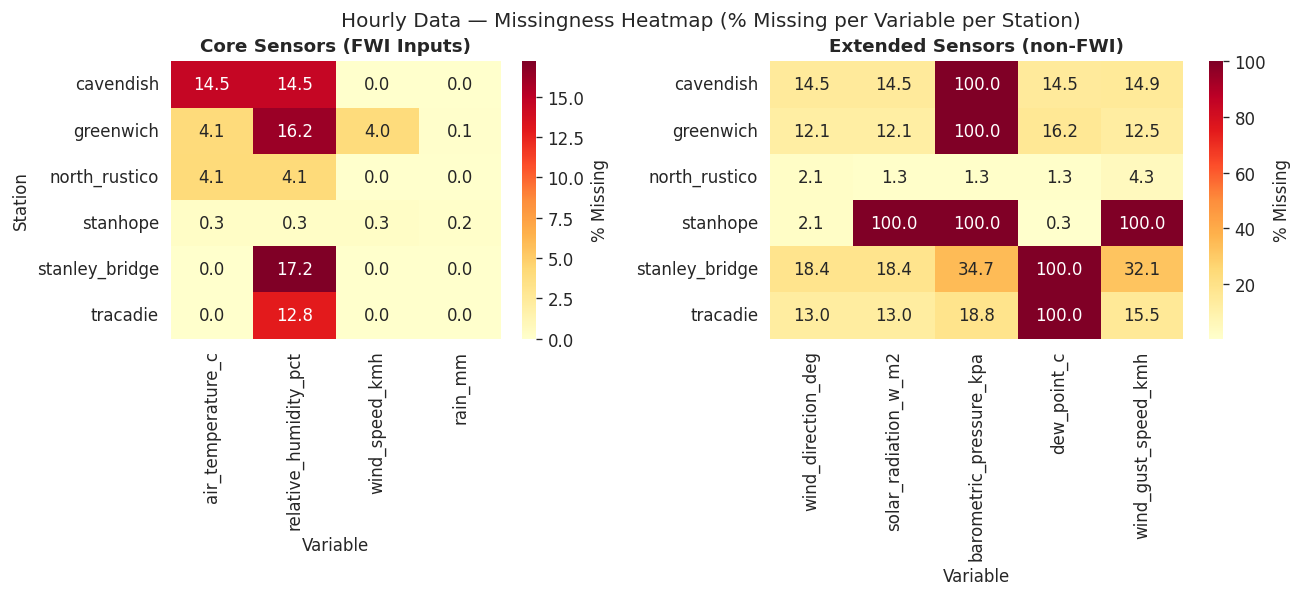

In [5]:
# --- Hourly missingness heatmap (core vs extended sensors) ---
FWI_CORE_VARS = [
    "air_temperature_c", "relative_humidity_pct",
    "wind_speed_kmh", "rain_mm",
]
HOURLY_EXTENDED_VARS = [
    "wind_direction_deg", "solar_radiation_w_m2",
    "barometric_pressure_kpa", "dew_point_c", "wind_gust_speed_kmh",
]

hourly_missing_frames = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath)
    df = df[pd.to_datetime(df["timestamp_utc"], utc=True) >= ANALYSIS_START]
    row = {"station": station}
    for var in FWI_CORE_VARS + HOURLY_EXTENDED_VARS:
        if var in df.columns:
            row[var] = df[var].isna().mean() * 100
        else:
            row[var] = 100.0
    hourly_missing_frames.append(row)

hourly_missing_df = pd.DataFrame(hourly_missing_frames).set_index("station")

# Split into core and extended panels
core_cols = [v for v in FWI_CORE_VARS if v in hourly_missing_df.columns]
ext_cols = [v for v in HOURLY_EXTENDED_VARS if v in hourly_missing_df.columns]

fig, (ax_core, ax_ext) = plt.subplots(
    1, 2, figsize=(max(12, (len(core_cols) + len(ext_cols)) * 1.1), max(3, len(stations) * 0.45)),
    gridspec_kw={"width_ratios": [len(core_cols), max(len(ext_cols), 1)], "wspace": 0.4},
)

sns.heatmap(
    hourly_missing_df[core_cols], annot=True, fmt=".1f", cmap="YlOrRd",
    ax=ax_core, cbar_kws={"label": "% Missing"},
)
ax_core.set_title("Core Sensors (FWI Inputs)", fontweight="bold", fontsize=11)
ax_core.set_xlabel("Variable")
ax_core.set_ylabel("Station")

if ext_cols:
    sns.heatmap(
        hourly_missing_df[ext_cols], annot=True, fmt=".1f", cmap="YlOrRd",
        ax=ax_ext, cbar_kws={"label": "% Missing"},
    )
else:
    ax_ext.text(0.5, 0.5, "No extended\nvariables", transform=ax_ext.transAxes,
                ha="center", va="center", fontsize=12, color="gray")
ax_ext.set_title("Extended Sensors (non-FWI)", fontweight="bold", fontsize=11)
ax_ext.set_xlabel("Variable")
ax_ext.set_ylabel("")

fig.suptitle("Hourly Data \u2014 Missingness Heatmap (% Missing per Variable per Station)",
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "missingness_heatmap_hourly.png", bbox_inches="tight")
print("Saved: notebooks/figures/missingness_heatmap_hourly.png")
print()
print("Hourly missingness summary (core):")
print(hourly_missing_df[core_cols].round(1).to_string())
print()
print("Hourly missingness summary (extended):")
print(hourly_missing_df[ext_cols].round(1).to_string())


### 2.3 Imputation Summary

Gaps filled per station per variable from the pipeline imputation report.


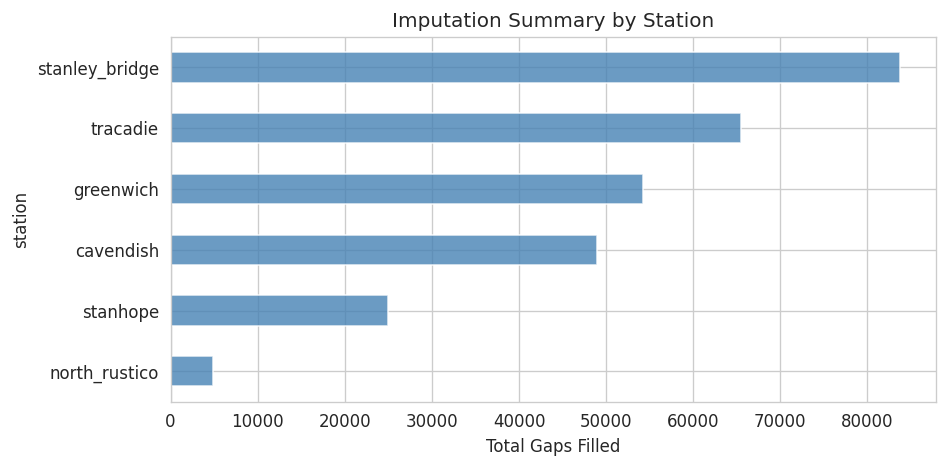

In [7]:
imp_path = PROCESSED_DIR / "imputation_report.csv"
if imp_path.exists():
    imp_df = pd.read_csv(imp_path)
    print(f"Imputation report: {len(imp_df)} entries")
    print("\nGaps filled per station per variable:")
    pivot = imp_df.groupby(["station", "variable"])["count_affected"].sum().reset_index()
    pivot_table = pivot.pivot(index="station", columns="variable", values="count_affected").fillna(0).astype(int)
    print(pivot_table.to_string())

    print("\nImputation method breakdown:")
    method_counts = imp_df["method"].value_counts()
    print(method_counts.to_string())

    # Bar chart: total gaps filled by station
    station_totals = imp_df.groupby("station")["count_affected"].sum().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    station_totals.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
    ax.set_xlabel("Total Gaps Filled")
    ax.set_title("Imputation Summary by Station")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "imputation_summary.png", bbox_inches="tight")
    print("Saved: notebooks/figures/imputation_summary.png")
else:
    print("imputation_report.csv not found — run pipeline first.")


## 3. Fire Weather Index Analysis

Time series of FWI system components for all stations with computed indices.


### 3.1 FWI Component Time Series

Daily-mean FWI components for all stations. FFMC uses hourly values; DMC, DC, BUI, FWI use daily means.

> **Finding.** All six stations show the expected seasonal pattern: FFMC and FWI ride near zero through the cold/wet months and spike into the high-danger range across summer. The slow codes (DMC, DC) climb gradually through the warm season and decay over winter, consistent with the Canadian FWI system behaving correctly. No station shows obviously anomalous values relative to its neighbours.


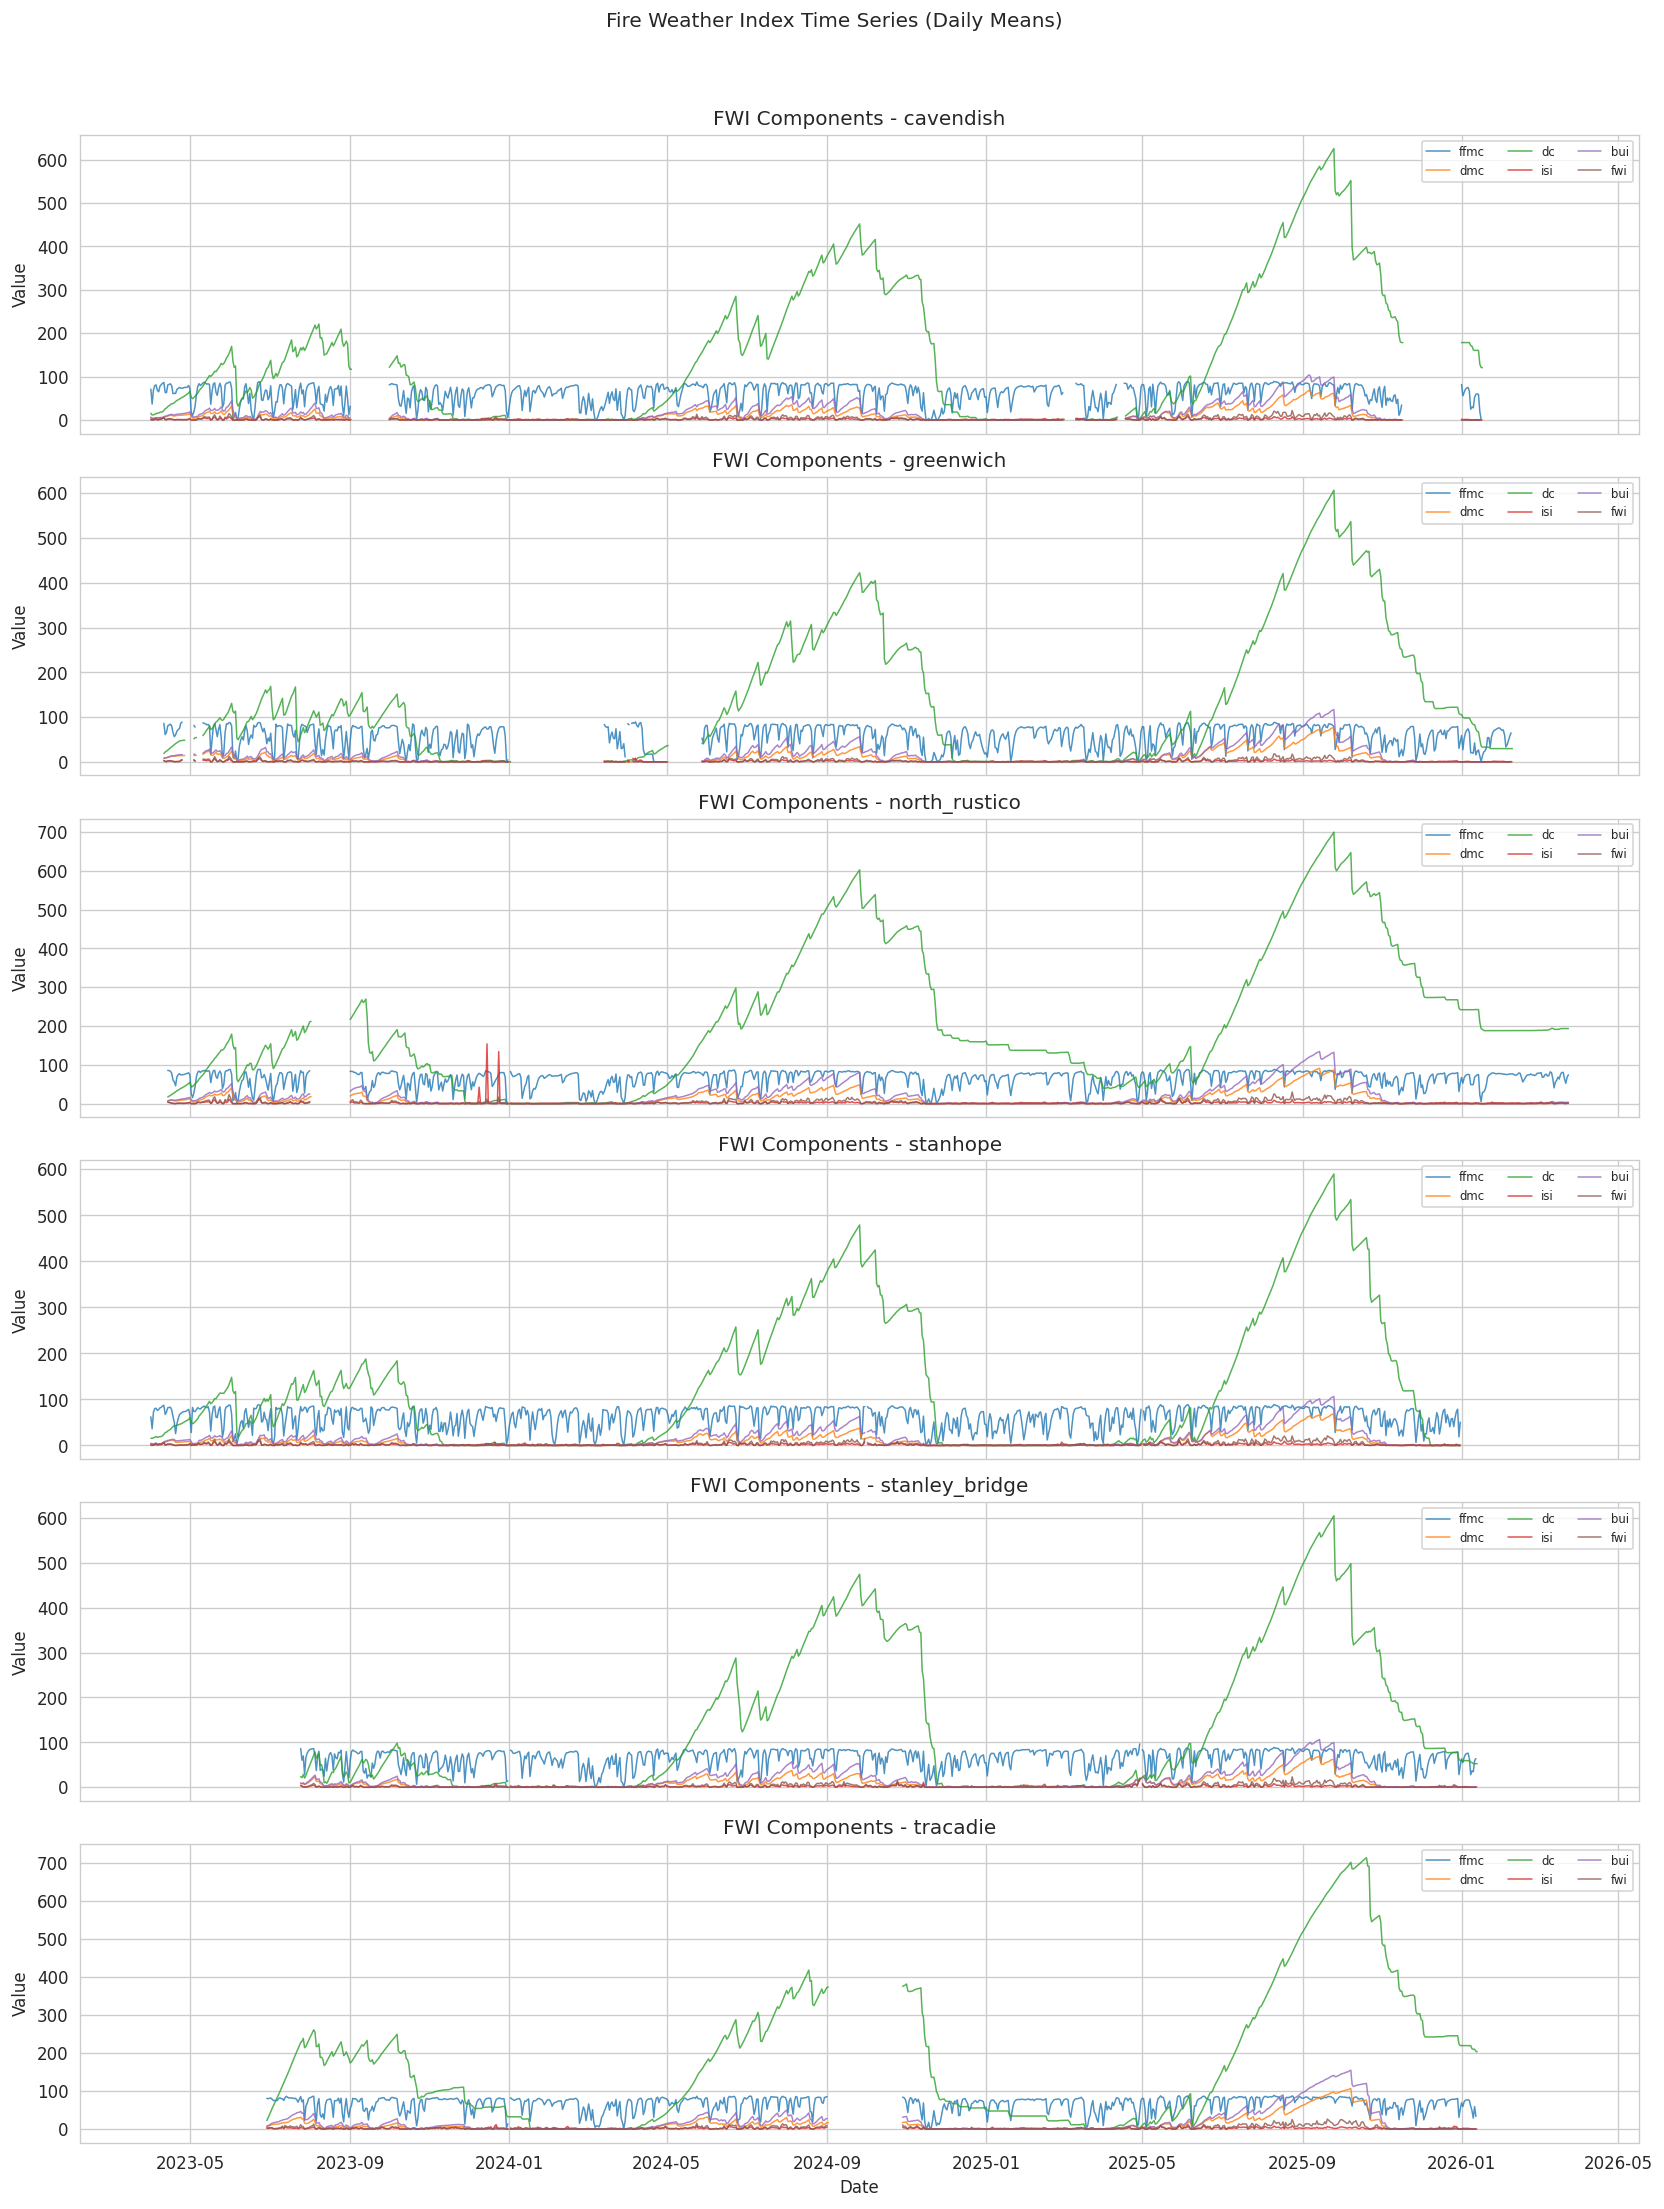

In [8]:
fwi_vars = ["ffmc", "dmc", "dc", "isi", "bui", "fwi"]

fwi_stations = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    if "fwi" in df.columns and df["fwi"].notna().sum() > 100:
        fwi_stations.append(station)

print(f"Stations with FWI data: {fwi_stations}")

if fwi_stations:
    fig, axes = plt.subplots(len(fwi_stations), 1, figsize=(14, 3 * len(fwi_stations)), sharex=True)
    if len(fwi_stations) == 1:
        axes = [axes]

    for idx, station in enumerate(fwi_stations):
        fpath = PROCESSED_DIR / station / "station_hourly.csv"
        df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
        df = df[df["timestamp_utc"] >= ANALYSIS_START]
        df_daily = df.set_index("timestamp_utc")[fwi_vars].resample("D").mean()
        ax = axes[idx]
        for var in fwi_vars:
            if var in df_daily.columns:
                ax.plot(df_daily.index, df_daily[var], label=var, alpha=0.8, linewidth=0.9)
        ax.set_ylabel("Value")
        ax.set_title(f"FWI Components - {station}")
        ax.legend(fontsize=7, ncol=3)

    axes[-1].set_xlabel("Date")
    fig.suptitle("Fire Weather Index Time Series (Daily Means)", y=1.02)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "fwi_timeseries.png", bbox_inches="tight")
    print(f"Plotted FWI for: {fwi_stations}")
    print("Saved: notebooks/figures/fwi_timeseries.png")
else:
    print("FWI analysis skipped: no stations with non-missing FWI data")


### 3.1b QF-Aware FWI Time Series

FWI values plotted with background shading indicating data quality.
- **Yellow band**: at least one FWI input was synthetically imputed (`qf == 1`)
- **Red band**: at least one FWI input was chain-break gap-filled (`qf == 9`)
- **No shading**: all FWI inputs from observed data (`qf == 0`)

Stations without per-variable `_qf` columns (stanhope) are skipped.

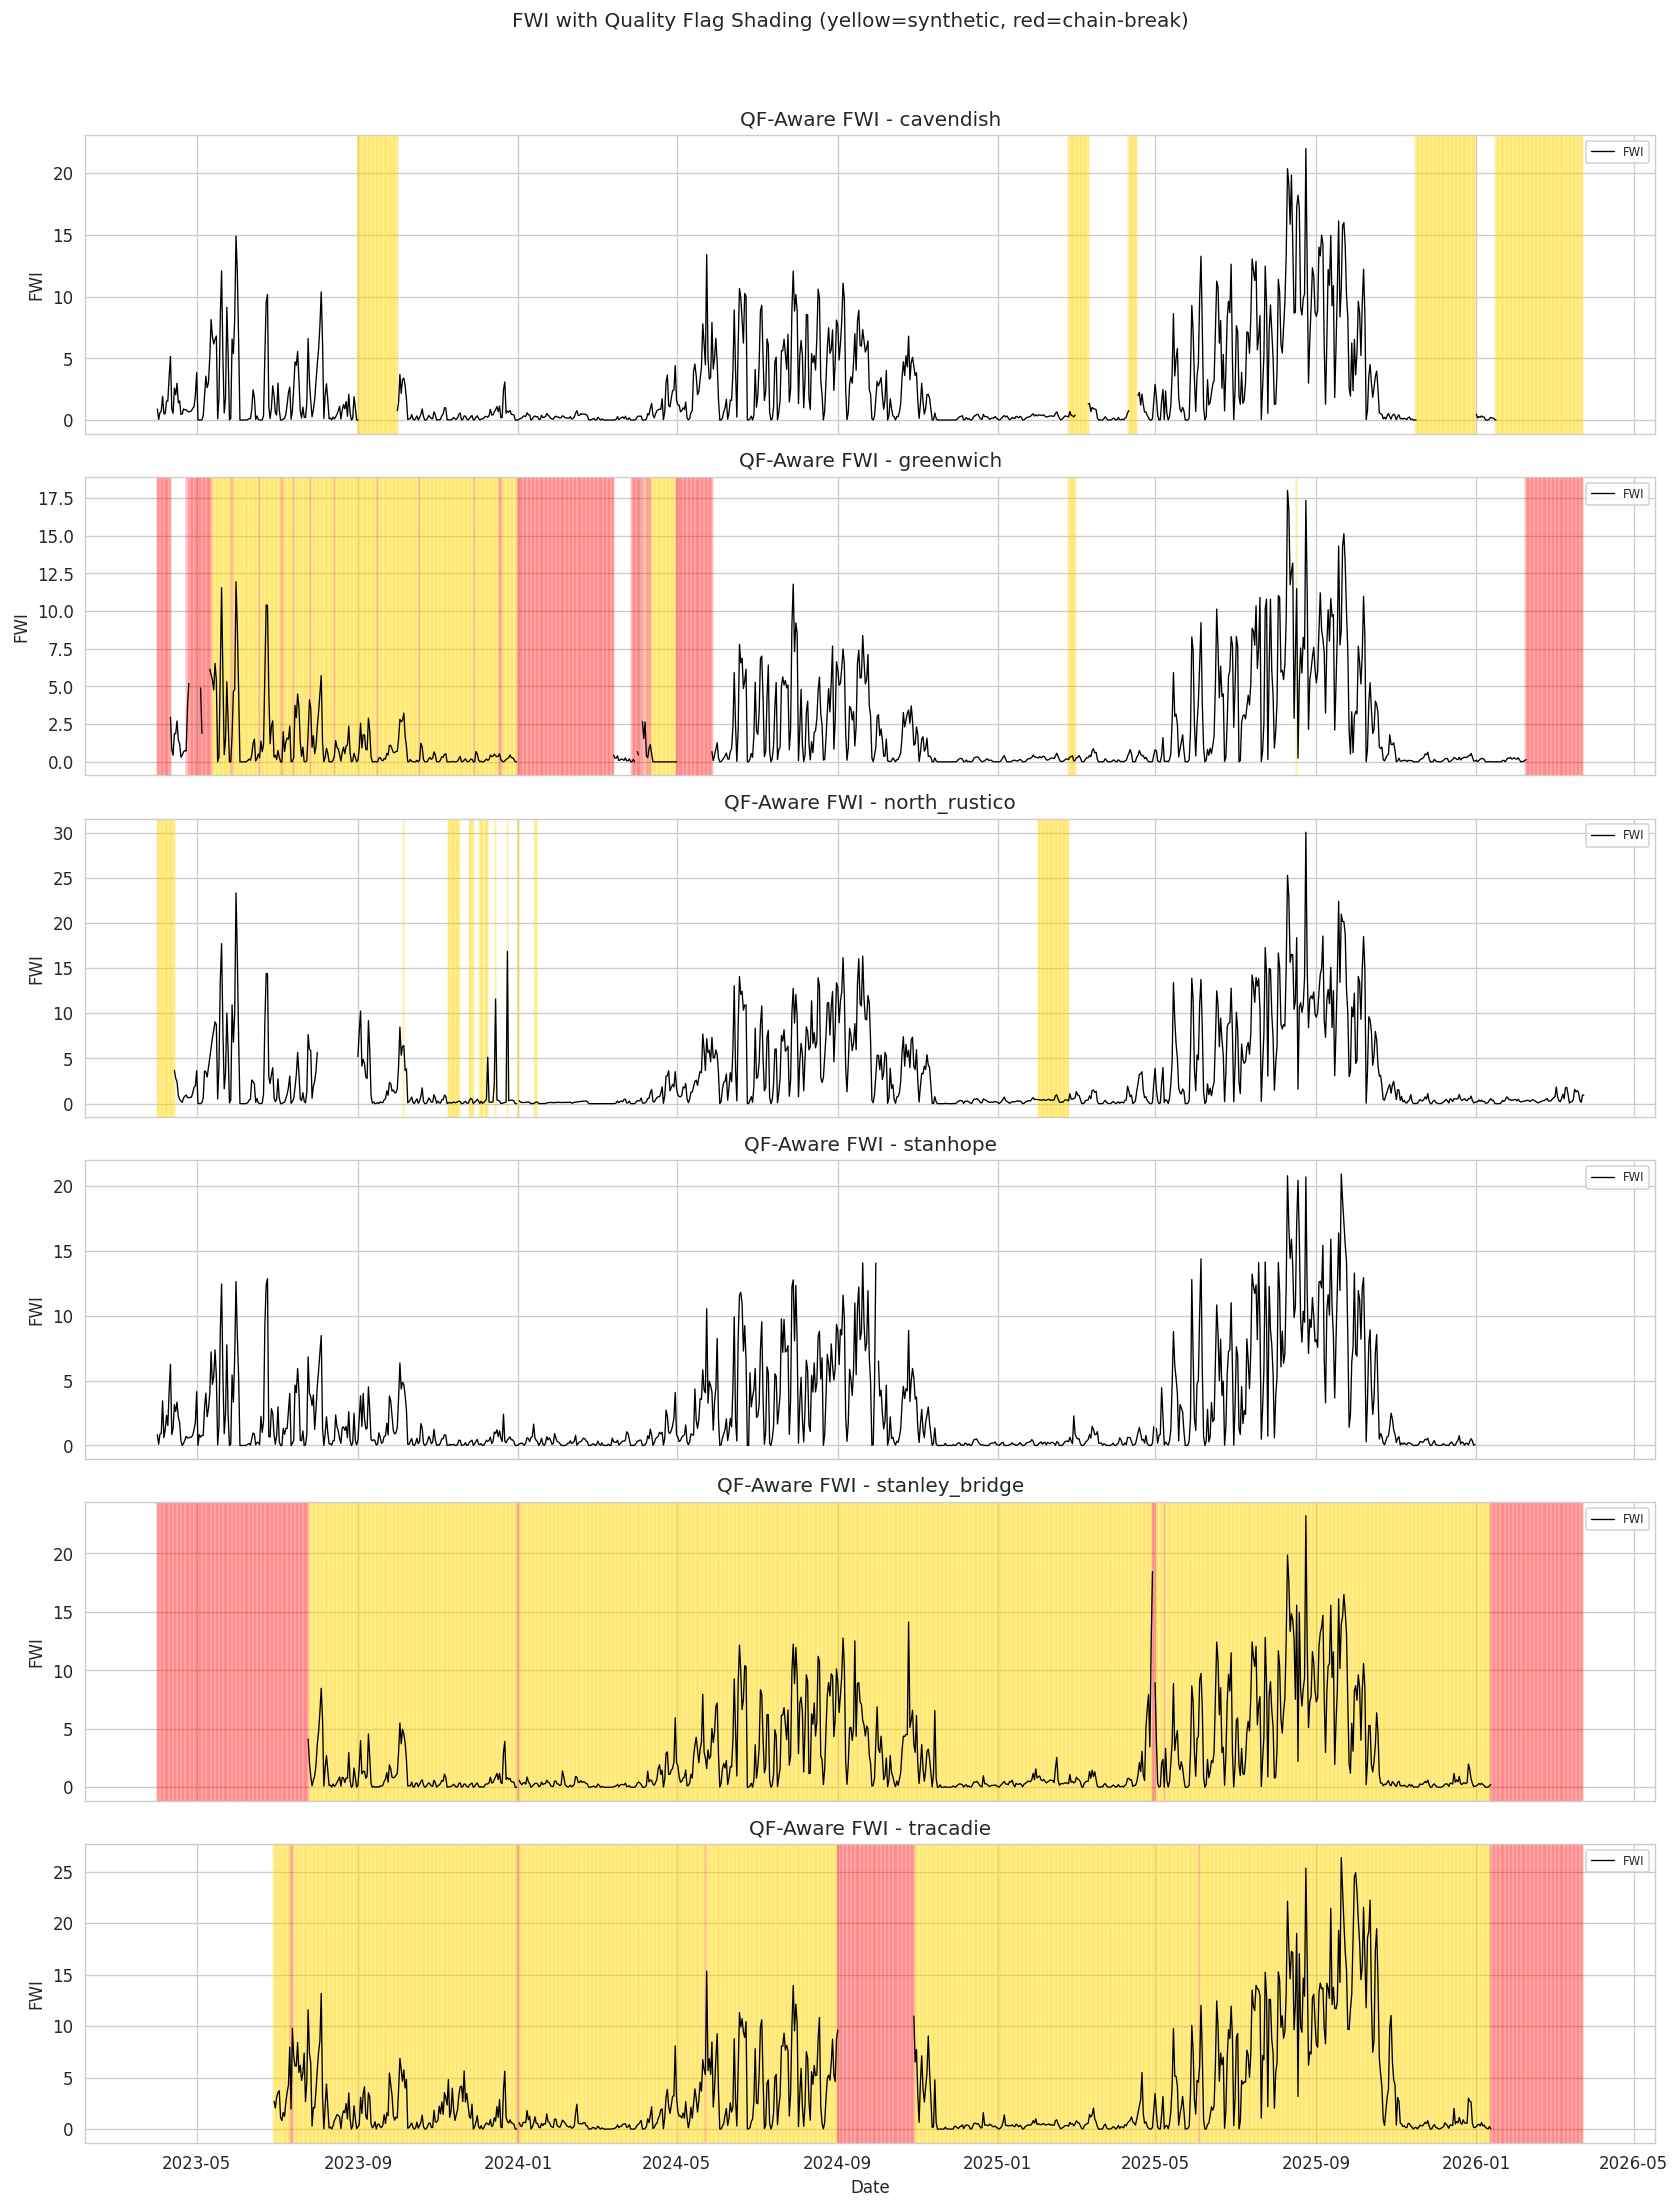

In [9]:
# --- QF-Aware FWI Timeseries ---
if fwi_stations:
    fig, axes = plt.subplots(len(fwi_stations), 1, figsize=(14, 3 * len(fwi_stations)), sharex=True)
    if len(fwi_stations) == 1:
        axes = [axes]

    fwi_input_qf = ["air_temperature_c_qf", "relative_humidity_pct_qf", "wind_speed_kmh_qf", "rain_mm_qf"]

    for idx, station in enumerate(fwi_stations):
        fpath = PROCESSED_DIR / station / "station_hourly.csv"
        df = pd.read_csv(fpath, parse_dates=["timestamp_utc"], low_memory=False)
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
        df = df[df["timestamp_utc"] >= ANALYSIS_START]
        ax = axes[idx]

        # Daily-mean FWI
        df_daily = df.set_index("timestamp_utc")[fwi_vars].resample("D").mean()

        # Daily quality: worst qf per day across all available input qf cols
        available_qf = [c for c in fwi_input_qf if c in df.columns]
        if available_qf:
            qf_daily = df.set_index("timestamp_utc")[available_qf].resample("D").max()
            worst_qf = qf_daily.max(axis=1)
        else:
            worst_qf = pd.Series(0, index=df_daily.index)

        # Background shading
        for i in range(len(worst_qf)):
            if worst_qf.iloc[i] >= 9:
                ax.axvspan(worst_qf.index[i] - pd.Timedelta(hours=12),
                          worst_qf.index[i] + pd.Timedelta(hours=12),
                          color='red', alpha=0.15)
            elif worst_qf.iloc[i] >= 1:
                ax.axvspan(worst_qf.index[i] - pd.Timedelta(hours=12),
                          worst_qf.index[i] + pd.Timedelta(hours=12),
                          color='gold', alpha=0.20)

        # FWI line
        ax.plot(df_daily.index, df_daily["fwi"], color="black", linewidth=0.8, label="FWI")
        ax.set_ylabel("FWI")
        ax.set_title(f"QF-Aware FWI - {station}")
        ax.legend(fontsize=7)

    axes[-1].set_xlabel("Date")
    fig.suptitle("FWI with Quality Flag Shading (yellow=synthetic, red=chain-break)", y=1.02)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "fwi_qf_aware.png", bbox_inches="tight")
    print("Saved: notebooks/figures/fwi_qf_aware.png")
else:
    print("QF-Aware FWI skipped: no stations with FWI data.")


### 3.2 FWI Mode Comparison

Overlay FWI values from hourly and compliant modes to show divergence (e.g., during chain breaks).


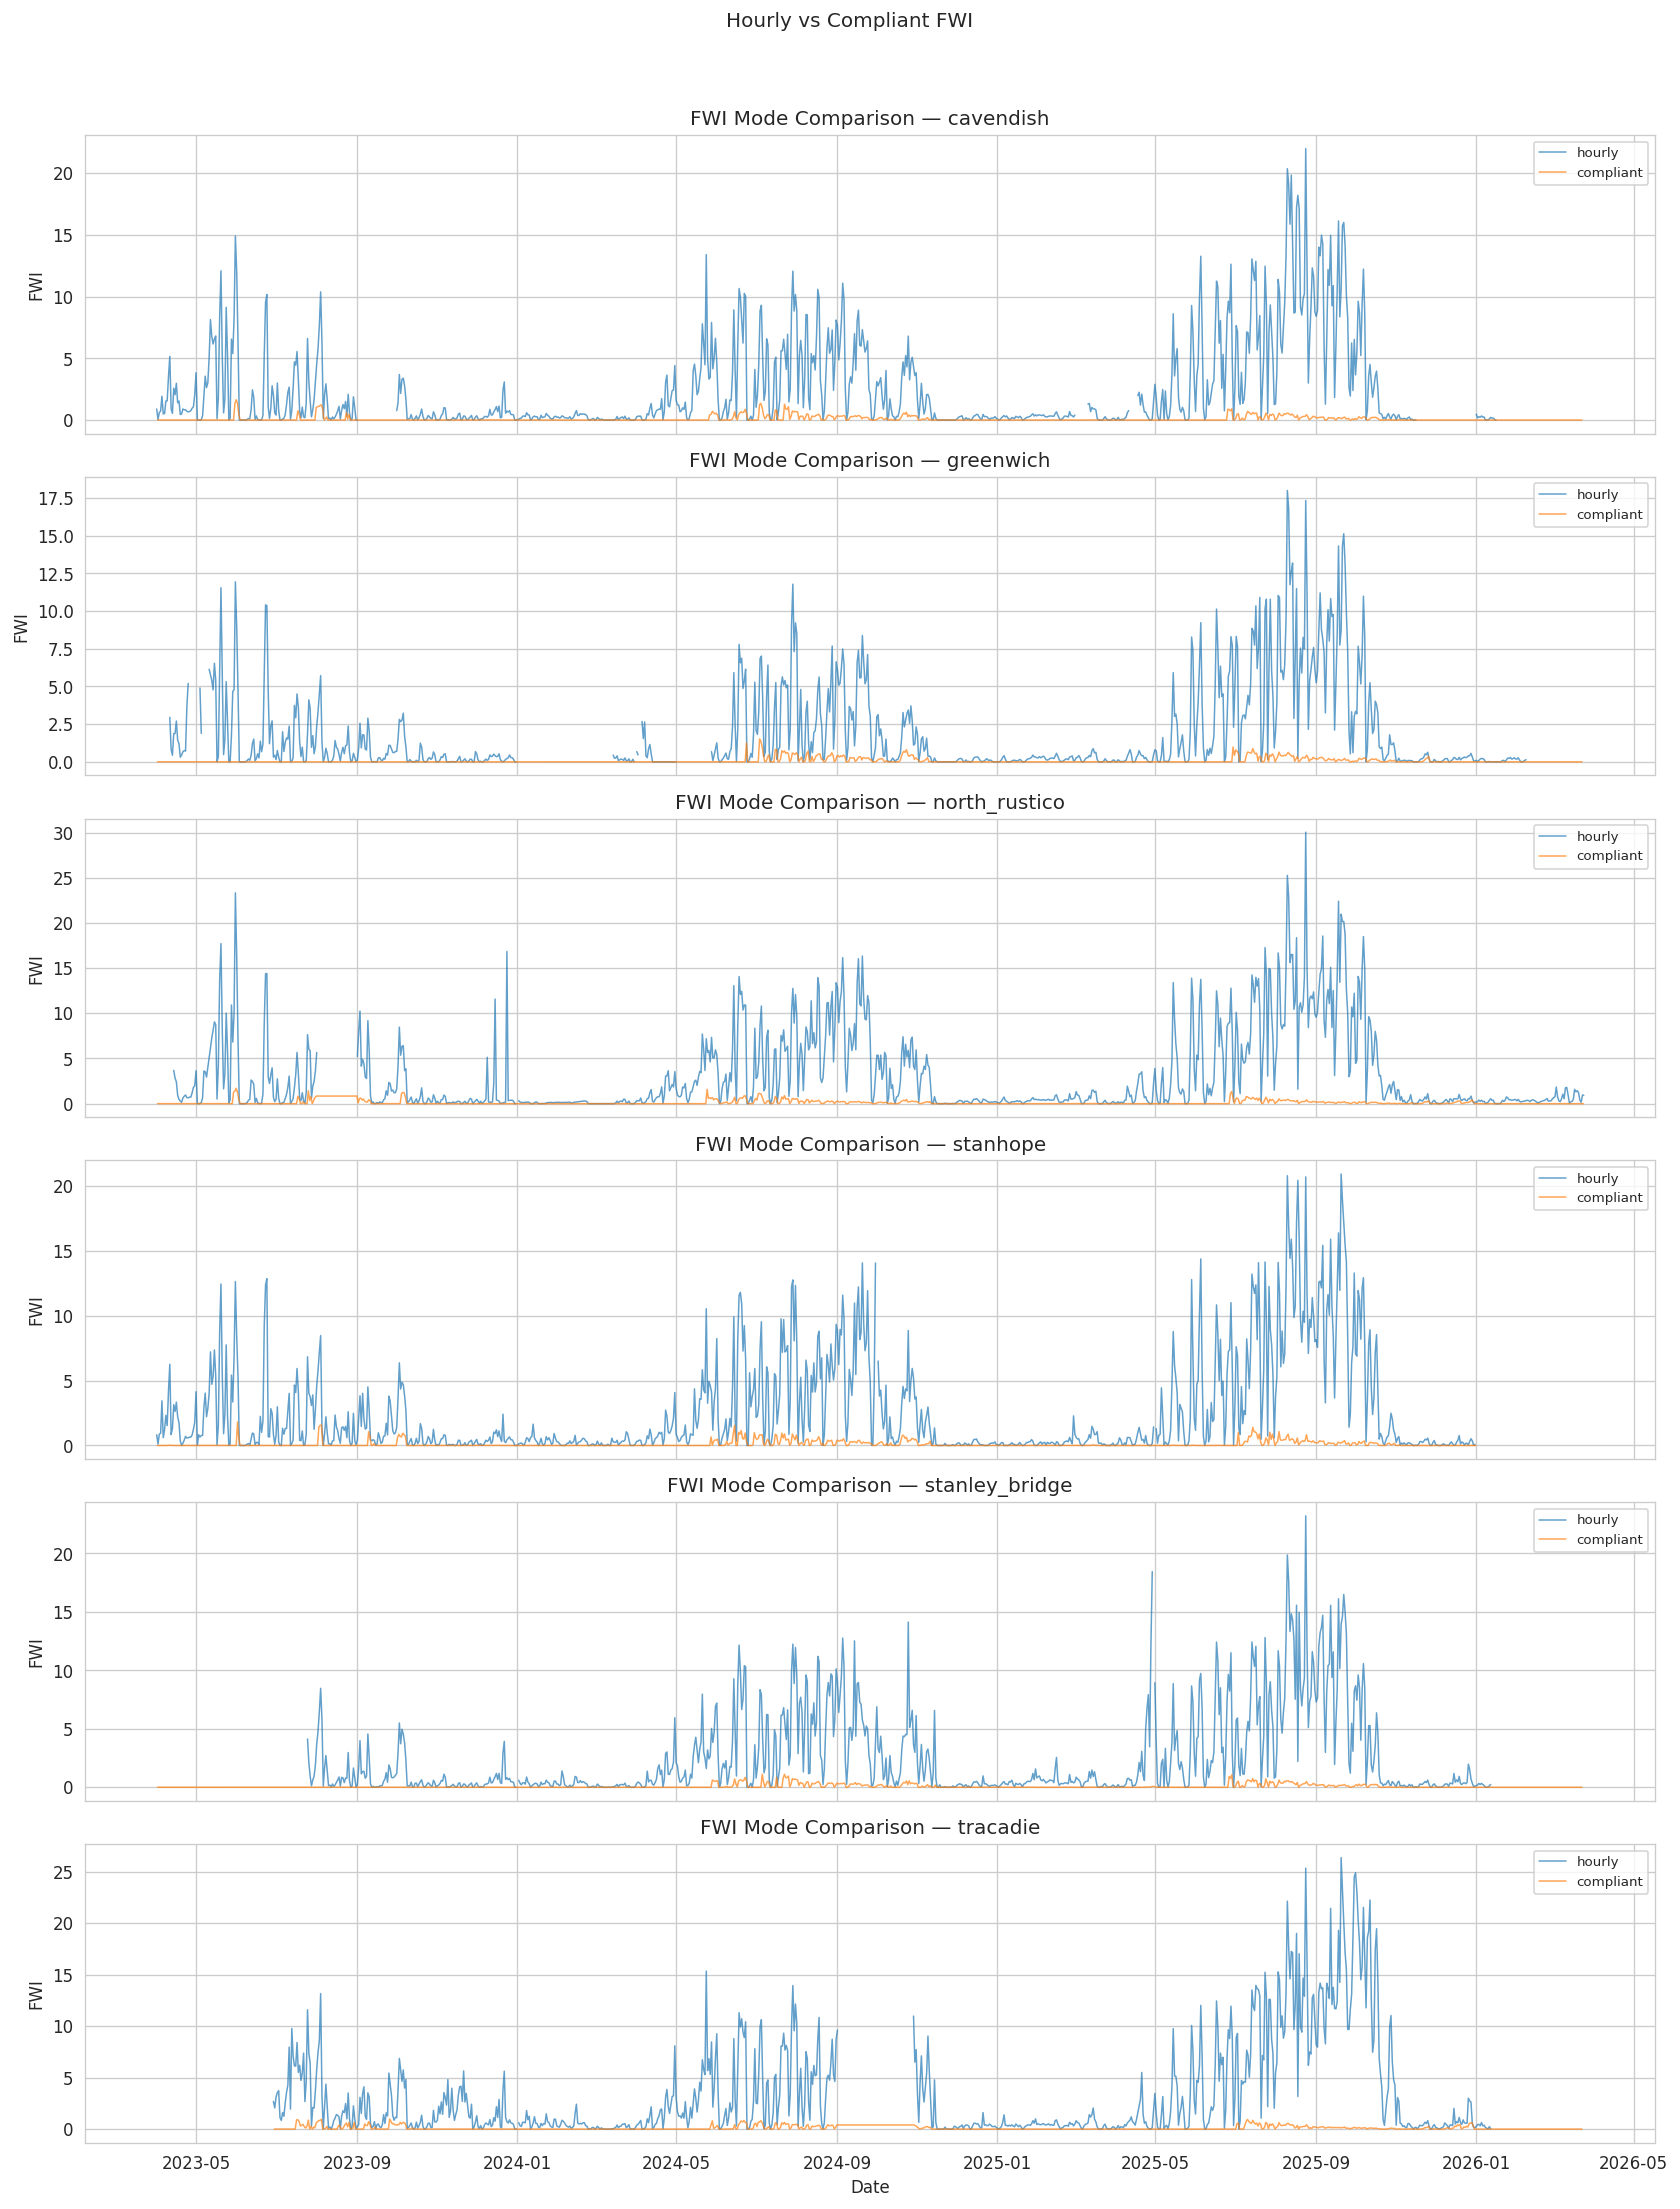

In [10]:
# Try to load both modes for comparison
hourly_fwi_data = {}
compliant_fwi_data = {}

for station in stations:
    h_path = PROCESSED_DIR / station / "station_hourly.csv"
    d_path = PROCESSED_DIR / station / "station_daily.csv"
    c_path = PROCESSED_DIR / station / f"{station}_daily_compliant.csv"

    if h_path.exists():
        df = pd.read_csv(h_path, parse_dates=["timestamp_utc"])
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
        df = df[df["timestamp_utc"] >= ANALYSIS_START]
        if "fwi" in df.columns and df["fwi"].notna().sum() > 0:
            hourly_fwi_data[station] = df.set_index("timestamp_utc")["fwi"].resample("D").mean()

    if c_path.exists():
        df_c = pd.read_csv(c_path, parse_dates=["timestamp_utc"])
        df_c["timestamp_utc"] = pd.to_datetime(df_c["timestamp_utc"], utc=True)
        df_c = df_c[df_c["timestamp_utc"] >= ANALYSIS_START]
        if "fwi" in df_c.columns and df_c["fwi"].notna().sum() > 0:
            compliant_fwi_data[station] = df_c.set_index("timestamp_utc")["fwi"]

compare_stations = sorted(set(hourly_fwi_data.keys()) & set(compliant_fwi_data.keys()))

if compare_stations:
    fig, axes = plt.subplots(len(compare_stations), 1, figsize=(14, 3 * len(compare_stations)), sharex=True)
    if len(compare_stations) == 1:
        axes = [axes]

    for idx, station in enumerate(compare_stations):
        ax = axes[idx]
        ax.plot(hourly_fwi_data[station].index, hourly_fwi_data[station].values, label="hourly", alpha=0.7, linewidth=0.9)
        ax.plot(compliant_fwi_data[station].index, compliant_fwi_data[station].values, label="compliant", alpha=0.7, linewidth=0.9)
        ax.set_ylabel("FWI")
        ax.set_title(f"FWI Mode Comparison — {station}")
        ax.legend(fontsize=8)

    axes[-1].set_xlabel("Date")
    fig.suptitle("Hourly vs Compliant FWI", y=1.02)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "fwi_mode_comparison.png", bbox_inches="tight")
    print(f"Mode comparison for: {compare_stations}")
    print("Saved: notebooks/figures/fwi_mode_comparison.png")
else:
    print("FWI mode comparison skipped: compliant-mode daily files not found.")
    print("Run the pipeline with --fwi-mode compliant to generate them.")


### 3.3 FWI Value Statistics

Per-station FWI value distributions (min, max, mean, std for FFMC / DMC / DC / ISI / BUI / FWI) are written to `data/processed/qa_qc_report_hourly.csv` by the pipeline. The headline read across the network — low absolute fire-weather values during the analysis window, with the maxima concentrated in late summer — is summarised in §7.1 and §7.2.


### 3.4 Chain Break Analysis

Analysis of FWI chain breaks by station and cause, sourced from the chain break diagnostic report.


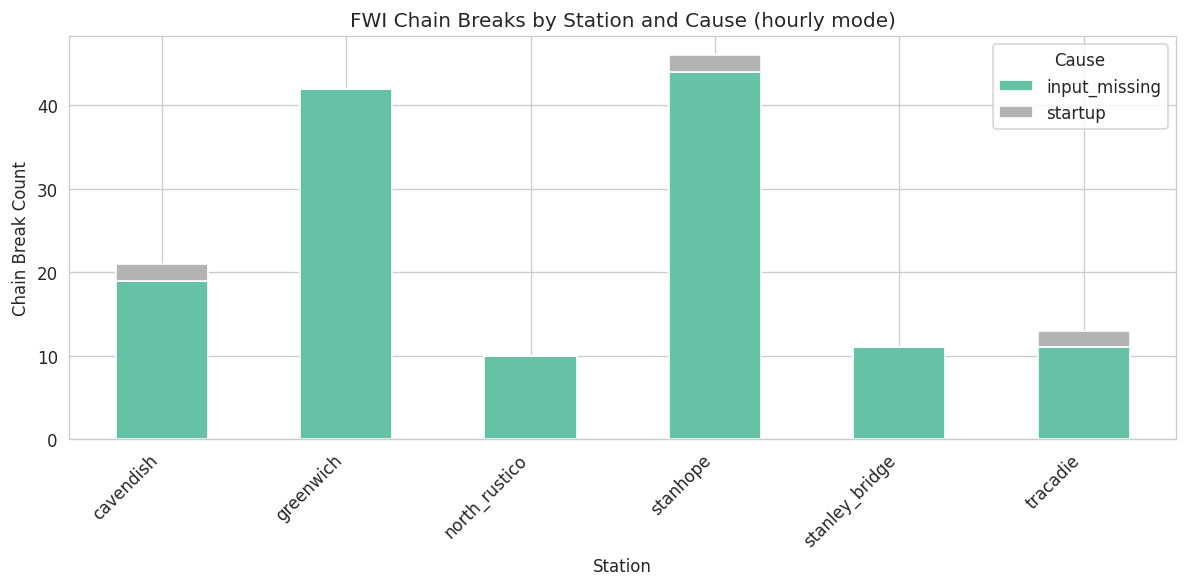

In [12]:
cb_path = PROCESSED_DIR / f"fwi_missingness_report_{FWI_MODE}.csv"
if cb_path.exists():
    cb_df = pd.read_csv(cb_path)
    print(f"Chain break report: {len(cb_df)} entries")

    # Summary table: breaks per station, grouped by cause
    if "cause" in cb_df.columns:
        print("\nBreaks per station by cause:")
        cause_pivot = cb_df.groupby(["station", "cause"]).size().reset_index(name="count")
        cause_table = cause_pivot.pivot(index="station", columns="cause", values="count").fillna(0).astype(int)
        print(cause_table.to_string())

        # Breakdown by missing input
        if "missing_input" in cb_df.columns:
            print("\nBreakdown by missing input:")
            input_counts = cb_df["missing_input"].value_counts()
            print(input_counts.to_string())

        # Bar chart: chain breaks by station, colored by cause
        fig, ax = plt.subplots(figsize=(10, 5))
        causes = cb_df["cause"].unique()
        station_breaks = cb_df.groupby(["station", "cause"]).size().unstack(fill_value=0)
        station_breaks.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
        ax.set_xlabel("Station")
        ax.set_ylabel("Chain Break Count")
        ax.set_title(f"FWI Chain Breaks by Station and Cause ({FWI_MODE} mode)")
        ax.legend(title="Cause")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        fig.savefig(FIGURES_DIR / "chain_breaks.png", bbox_inches="tight")
        print("Saved: notebooks/figures/chain_breaks.png")

        # Cascade origins table
        cascade = cb_df[cb_df["cause"] == "cascade"]
        if len(cascade) > 0 and "cascade_origin" in cascade.columns:
            print("\nCascade origins:")
            print(cascade[["station", "cascade_origin"]].to_string(index=False))
    else:
        print("Chain break report has no 'cause' column. Columns:", list(cb_df.columns))
else:
    print(f"fwi_missingness_report_{FWI_MODE}.csv not found — no chain breaks or pipeline not run.")


## 4. Data Quality Report

Quality metrics from the QA/QC report, quality enforcement actions, and cross-station imputation audit.


### 4.1 Pre/Post Imputation Missingness

Per-station missingness percentage on each core FWI input, before and after the imputation pipeline. Bold cells with an arrow indicate the values changed; cells where pre = post show the pipeline did not impute that variable for that station (either because the gap was zero or because no donor is configured).

| Station | Air Temp | Rel. Humidity | Wind Speed | Rain |
|---|---:|---:|---:|---:|
| **Stanhope** | 0.3 → 0.3 | 0.3 → 0.3 | 0.3 → 0.3 | 0.2 → 0.2 |
| **Greenwich** | **38.9 → 4.1** (↓34.9) | **16.2 → 16.2** (↓0.0) | **12.4 → 4.0** (↓8.5) | 0.1 → 0.1 |
| **Cavendish** | 14.5 → 14.5 | 14.5 → 14.5 | **14.9 → 0.0** (↓14.9) | 0.0 → 0.0 |
| **North Rustico** | 4.1 → 4.1 | 4.1 → 4.1 | **4.5 → 0.0** (↓4.5) | 0.0 → 0.0 |
| **Stanley Bridge** | **17.2 → 0.0** (↓17.2) | **100.0 → 17.2** (↓82.8) | **32.1 → 0.0** (↓32.1) | 0.0 → 0.0 |
| **Tracadie** | **12.8 → 0.0** (↓12.8) | **100.0 → 12.8** (↓87.2) | **15.9 → 0.0** (↓15.9) | 0.0 → 0.0 |

\* Cavendish and North Rustico show no temperature or RH change because the cross-station donor config does not list a donor for those two stations on those variables — only their wind channel is imputed. This is a config decision, not a pipeline failure.

The full pre/post counts are available in `data/processed/qa_qc_report_hourly.csv`.


### 4.2 Quality Enforcement Actions

Count of quality enforcement actions by type and station.


In [14]:
qe_path = PROCESSED_DIR / "quality_enforcement_report.csv"
if qe_path.exists():
    qe_df = pd.read_csv(qe_path)
    print(f"Quality enforcement report: {len(qe_df)} actions")

    if "action" in qe_df.columns and "station" in qe_df.columns:
        print("\nActions by type and station:")
        action_pivot = qe_df.groupby(["station", "action"]).size().reset_index(name="count")
        action_table = action_pivot.pivot(index="station", columns="action", values="count").fillna(0).astype(int)
        print(action_table.to_string())
    else:
        print("Columns:", list(qe_df.columns))
else:
    print("quality_enforcement_report.csv not found.")


### 4.3 Out-of-Range Summary

Out-of-range counts for temperature, RH, and wind per station from the QA/QC report.

> **Why these counts are zero.** Out-of-range values are corrected upstream by the quality-enforcement pass (see Section 4.2). The columns shown here are the *post-enforcement* state, so a clean run is expected to report all zeros. The pre-enforcement column (`out_of_range_pre_enforcement`) shows what was caught and fixed.


In [15]:
qa_qc_path = PROCESSED_DIR / f"qa_qc_report_{FWI_MODE}.csv"
if qa_qc_path.exists():
    qa_df = pd.read_csv(qa_qc_path)
    oor_cols = [c for c in qa_df.columns if "out_of_range" in c.lower()]
    if oor_cols:
        print("Out-of-Range Summary:")
        print(qa_df[["station"] + oor_cols].to_string(index=False))
    else:
        print("No out-of-range columns in QA/QC report.")
else:
    print(f"qa_qc_report_{FWI_MODE}.csv not found.")


### 4.2b Quality Enforcement Summary (Visual)

Stacked bar chart of quality enforcement actions by station.
Each bar segment represents an action type (set_nan, clip, etc.).

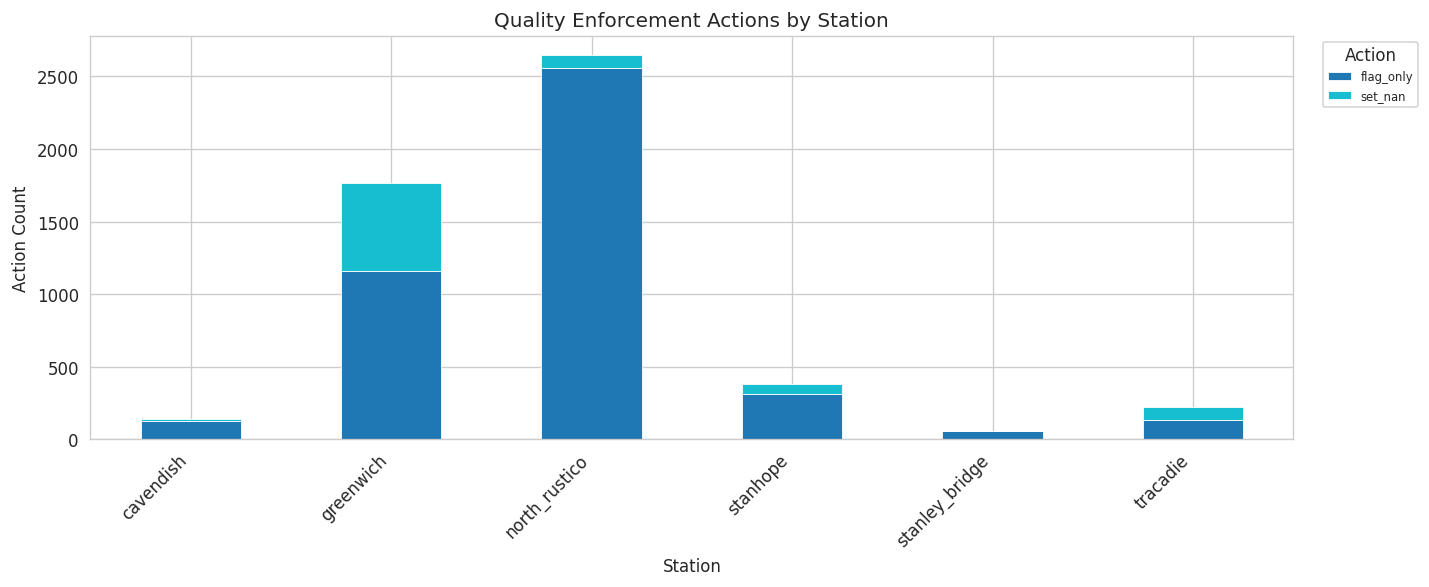

In [16]:
# --- Quality Enforcement Stacked Bar ---
qe_path = PROCESSED_DIR / "quality_enforcement_report.csv"
if qe_path.exists():
    qe_df = pd.read_csv(qe_path)
    pivot = qe_df.groupby(["station", "action"]).size().reset_index(name="count")
    pivot_table = pivot.pivot(index="station", columns="action", values="count").fillna(0).astype(int)

    fig, ax = plt.subplots(figsize=(12, 5))
    pivot_table.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", edgecolor="white", linewidth=0.5)
    ax.set_title("Quality Enforcement Actions by Station")
    ax.set_xlabel("Station")
    ax.set_ylabel("Action Count")
    ax.legend(title="Action", fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "quality_enforcement_stacked.png", bbox_inches="tight")
    print("Saved: notebooks/figures/quality_enforcement_stacked.png")
else:
    print("quality_enforcement_report.csv not found.")


### 4.2c Synthetic Data Proportion Heatmap

Percentage of rows with `qf > 0` (synthetic or chain-break) per station per variable.
Higher values indicate greater reliance on imputed/synthetic data.
Stations without `_qf` columns for a variable are shown as N/A.

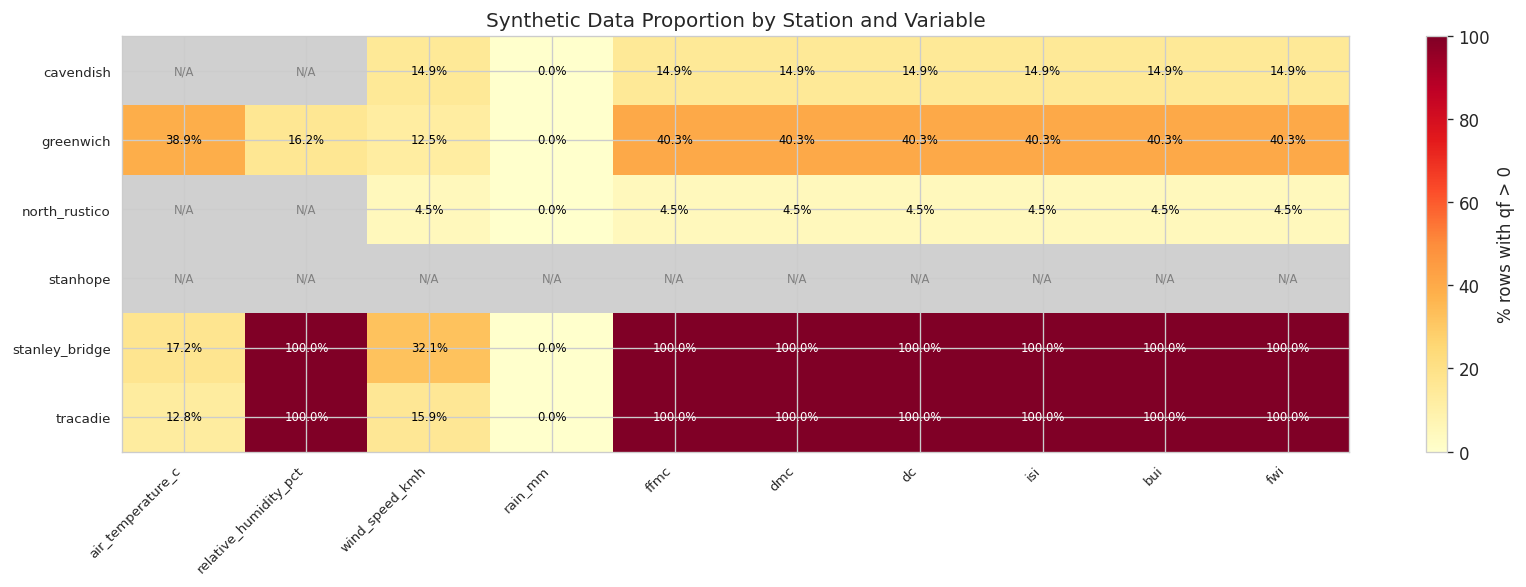

In [17]:
# --- Synthetic Data Proportion Heatmap ---
qf_vars = [
    "air_temperature_c_qf", "relative_humidity_pct_qf",
    "wind_speed_kmh_qf", "rain_mm_qf",
    "ffmc_qf", "dmc_qf", "dc_qf", "isi_qf", "bui_qf", "fwi_qf"
]
prop_matrix = {}
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, low_memory=False)
    row = {}
    for qv in qf_vars:
        if qv in df.columns:
            row[qv.replace("_qf", "")] = (df[qv] > 0).mean() * 100
        else:
            row[qv.replace("_qf", "")] = float("nan")
    prop_matrix[station] = row

prop_df = pd.DataFrame(prop_matrix).T

fig, ax = plt.subplots(figsize=(14, 5))
mask = prop_df.isna()
cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color="#d0d0d0")
im = ax.imshow(prop_df.values, cmap=cmap, aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(prop_df.columns)))
ax.set_xticklabels(prop_df.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(prop_df.index)))
ax.set_yticklabels(prop_df.index, fontsize=8)

# Annotate cells
for i in range(len(prop_df.index)):
    for j in range(len(prop_df.columns)):
        v = prop_df.iloc[i, j]
        if pd.isna(v):
            ax.text(j, i, "N/A", ha="center", va="center", fontsize=7, color="gray")
        else:
            ax.text(j, i, f"{v:.1f}%", ha="center", va="center", fontsize=7,
                    color="white" if v > 50 else "black")

fig.colorbar(im, ax=ax, label="% rows with qf > 0")
ax.set_title("Synthetic Data Proportion by Station and Variable")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "synthetic_proportion_heatmap.png", bbox_inches="tight")
print("Saved: notebooks/figures/synthetic_proportion_heatmap.png")


### 4.2d Quality Flag Timeline

Stacked horizontal bars showing the count of quality flags raised per flag type. Each row is a flag type (value-range, rate-of-change, flatline, cross-variable, stuck-sensor); colour segments inside the bar show which station the flags came from. Flag types with no observations across the network are omitted.


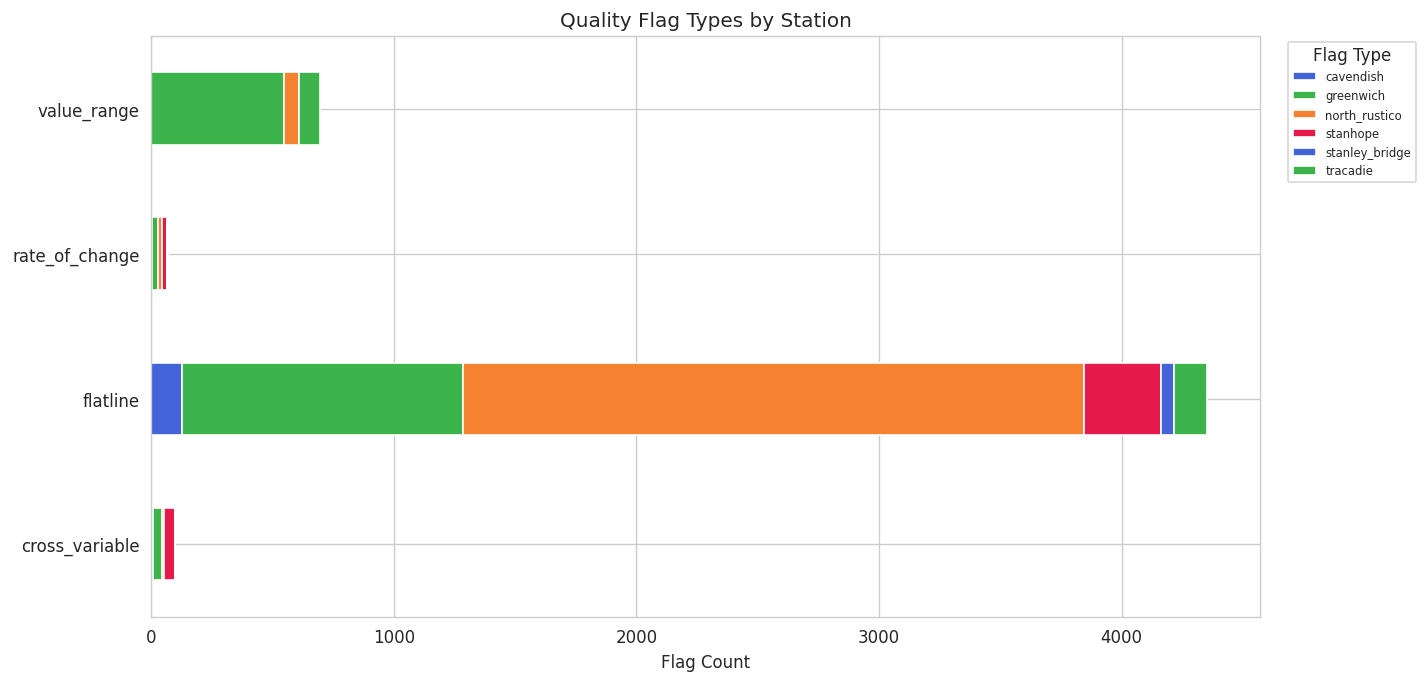

In [18]:
# --- Quality Flag Timeline ---
import ast

flag_color_map = {
    "value_range": "#e6194b",     # red
    "rate_of_change": "#f58231",  # orange
    "flatline": "#3cb44b",        # green
    "cross_variable": "#4363d8",  # blue
    "stuck_sensor": "#911eb4",    # purple
}

flag_data = {}
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"], low_memory=False)
    if "_quality_flags" not in df.columns:
        continue
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    # Parse flag lists and extract types
    flag_types = []
    for val in df["_quality_flags"].dropna():
        try:
            flags = ast.literal_eval(val) if isinstance(val, str) else val
            for f in flags:
                ftype = f.split(":")[0] if ":" in str(f) else str(f)
                flag_types.append(ftype)
        except Exception:
            pass
    if flag_types:
        flag_data[station] = pd.Series(flag_types).value_counts()

if flag_data:
    # Index = flag type, columns = stations. Transpose so each barh row
    # is one station and the stacked colour segments are flag types
    # — matching the §4.2d description.
    flag_df = pd.DataFrame(flag_data).fillna(0).astype(int).T
    fig, ax = plt.subplots(figsize=(11, 1.0 + 0.6 * len(flag_df.index)))
    flag_df.plot(
        kind="barh", stacked=True, ax=ax,
        color=[flag_color_map.get(t, "#aaa") for t in flag_df.columns],
        edgecolor="white", linewidth=0.4,
    )
    ax.set_title("Quality Flag Types by Station")
    ax.set_xlabel("Flag Count")
    ax.set_ylabel("")
    ax.legend(title="Flag Type", fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "quality_flag_timeline.png", bbox_inches="tight")
    print("Saved: notebooks/figures/quality_flag_timeline.png")
else:
    print("No quality flag data found for any station.")


### 4.4 Cross-Station Imputation Audit

Donor-to-recipient imputation pairs and counts.


In [19]:
cs_path = PROCESSED_DIR / "cross_station_imputation_audit.csv"
if cs_path.exists():
    cs_df = pd.read_csv(cs_path)
    print(f"Cross-station imputation audit: {len(cs_df)} entries")

    if "donor" in cs_df.columns and "target" in cs_df.columns:
        print("\nDonor -> Recipient pairs:")
        pairs = cs_df.groupby(["donor", "target"]).size().reset_index(name="count")
        print(pairs.to_string(index=False))
    else:
        print("Columns:", list(cs_df.columns))
else:
    print("cross_station_imputation_audit.csv not found.")


### 4.4b Cross-Station Donor Audit (Visual)

Dual-panel chart:

- **Left — Donor Contribution Count (in-network):** how many values each PEA station contributed as a donor to the cross-station imputer. Sources in the audit are prefixed `INTERNAL:` to mark them as in-network (as opposed to hypothetical external fallback). **100% of imputations were resolved from in-network donors — no external data source was needed.**
- **Right — Imputation Method by Station:** which method (`SPATIAL_PROXY_RAW`, `SPATIAL_PROXY`, `DIRECT_RH`) supplied each station's imputed values. Combined with the left panel this shows who depends on whom and by what route.


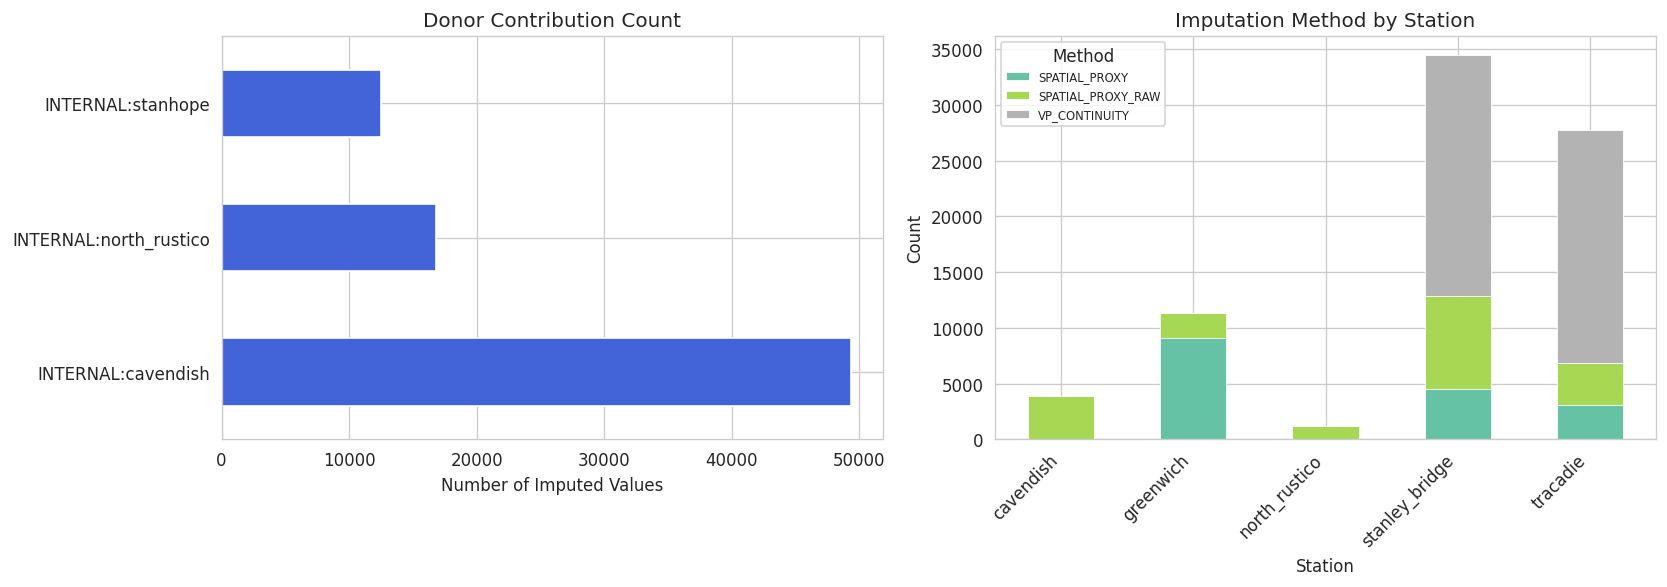

In [20]:
# --- Cross-Station Donor Audit Visual ---
cs_path = PROCESSED_DIR / "cross_station_imputation_audit.csv"
if cs_path.exists():
    cs_df = pd.read_csv(cs_path)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: donor contributions. Sources in the audit are prefixed
    # `INTERNAL:` to mark them as in-network (vs hypothetical external
    # fallback). Strip the prefix for readable labels.
    if "source" in cs_df.columns:
        donor_series = cs_df["source"].str.replace("^INTERNAL:", "", regex=True)
        donor_counts = donor_series.value_counts()
        donor_counts.plot(kind="barh", ax=ax1, color="#4363d8", edgecolor="white")
        ax1.set_title("Donor Contribution Count (in-network)")
        ax1.set_xlabel("Number of Imputed Values")
        ax1.set_ylabel("Donor Station")
        external_count = int((~cs_df["source"].fillna("").str.startswith("INTERNAL:")).sum())
        if external_count == 0:
            ax1.text(
                0.98, 0.02,
                "100% in-network — 0 external fallback",
                transform=ax1.transAxes,
                ha="right", va="bottom",
                fontsize=8, style="italic", color="#555",
            )
    else:
        ax1.text(0.5, 0.5, "No source column", ha="center", va="center", transform=ax1.transAxes)

    # Right: method breakdown by station
    if "station" in cs_df.columns and "method" in cs_df.columns:
        method_pivot = cs_df.groupby(["station", "method"]).size().reset_index(name="count")
        method_table = method_pivot.pivot(index="station", columns="method", values="count").fillna(0).astype(int)
        method_table.plot(kind="bar", stacked=True, ax=ax2, colormap="Set2", edgecolor="white", linewidth=0.5)
        ax2.set_title("Imputation Method by Station")
        ax2.set_xlabel("Station")
        ax2.set_ylabel("Count")
        ax2.legend(title="Method", fontsize=7)
        plt.xticks(rotation=45, ha="right")
    else:
        ax2.text(0.5, 0.5, "No method/station columns", ha="center", va="center", transform=ax2.transAxes)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "cross_station_donor_audit.png", bbox_inches="tight")
    print("Saved: notebooks/figures/cross_station_donor_audit.png")
else:
    print("cross_station_imputation_audit.csv not found.")


## 5. Redundancy Analysis

> **Method.** The previous PR carried three separate redundancy sections — a temperature-only PCA (§5), a temperature-only clustering dendrogram (§6), and a Stanhope-benchmark + recommendations table (§7) — followed by a multivariate consolidation (§7.5). The single-variable temperature view consistently overstates redundancy because PC1 on temperature is dominated by the shared seasonal/diurnal signal that every station records the same way. The substantive redundancy evidence comes from repeating the analysis on all four FWI inputs (temperature, relative humidity, wind speed, precipitation), checking leave-one-out donor impact in the imputation network, partialing out the shared regional weather, and restricting correlation to extreme-event rows. Those four pieces are below; the full per-variable matrices and bootstrap intervals are in the [Extended Redundancy Report](redundancy_extended.html).

### Single-variable PCA — temperature is the outlier, not the rule


Temperature is highly redundant across the network (PC1 = 0.963), but treating all four FWI inputs as if they tracked together overstates the picture. Repeating the PCA on the other FWI inputs:

| Variable | PC1 share of variance | Confidently-redundant pairs (95% bootstrap CI lower > 0.95) |
|---|---|---|
| Air temperature | **0.963** | 6 of 15 |
| Relative humidity | 0.793 | 0 of 15 |
| Wind speed | 0.709 | 0 of 15 |
| Precipitation | 0.547 | 0 of 15 |

Only air temperature supports any "remove" recommendation. The per-variable recommendation matrix from the [Extended Redundancy Report](redundancy_extended.html) confirms it — every station gets "defer" on RH, wind, and precipitation:

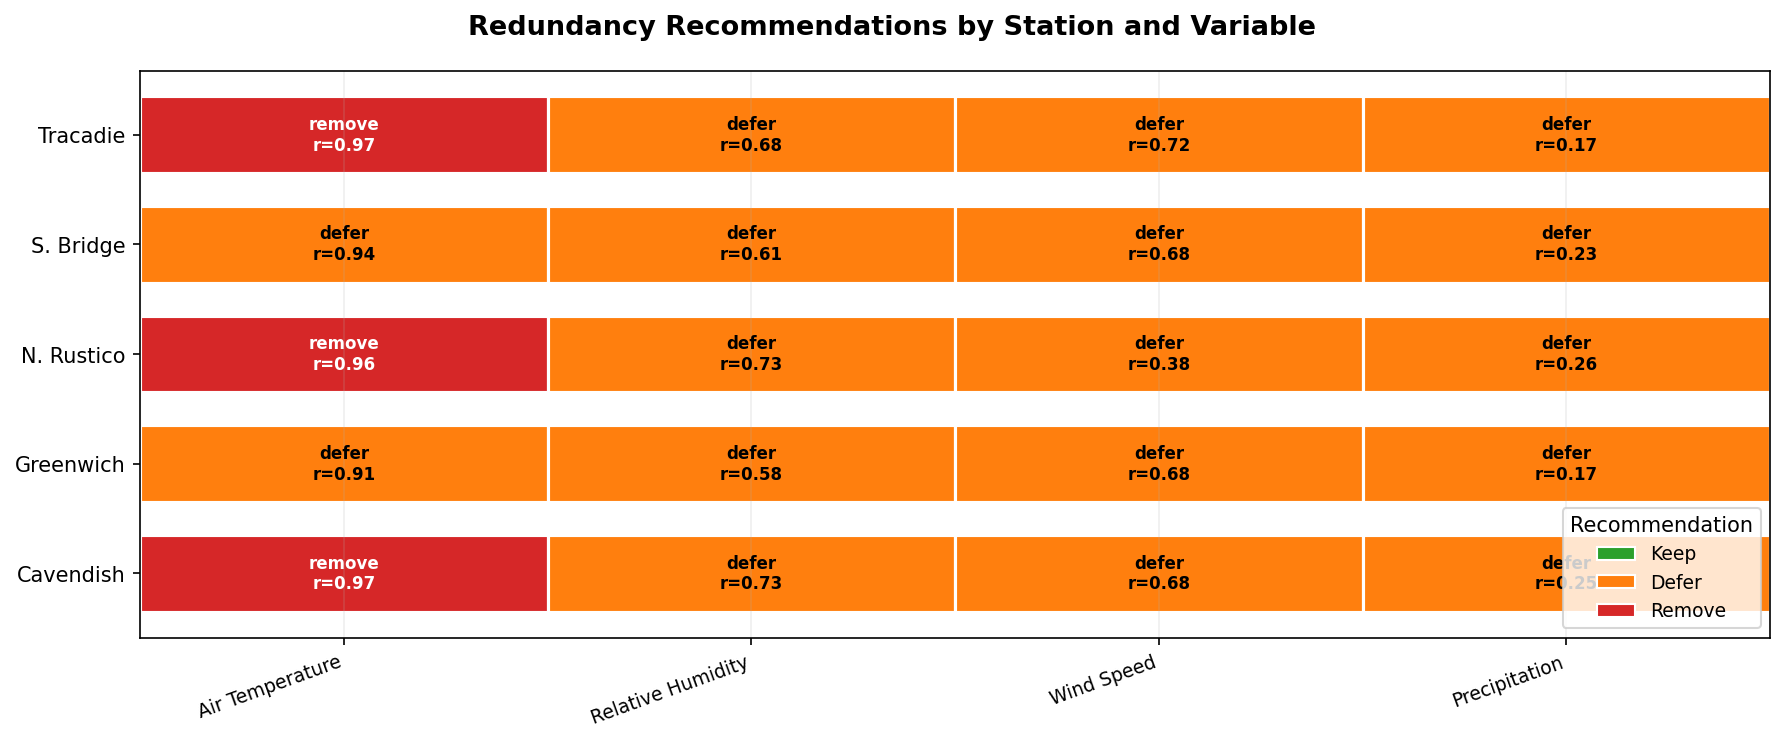

### Leave-one-out station-removal impact

The most direct redundancy test asks: if a station is removed from the network, how many FWI values at the *other* stations change? The cross-station imputation audit records donor-to-recipient provenance for every imputed value, so this is a deterministic count, not a model.

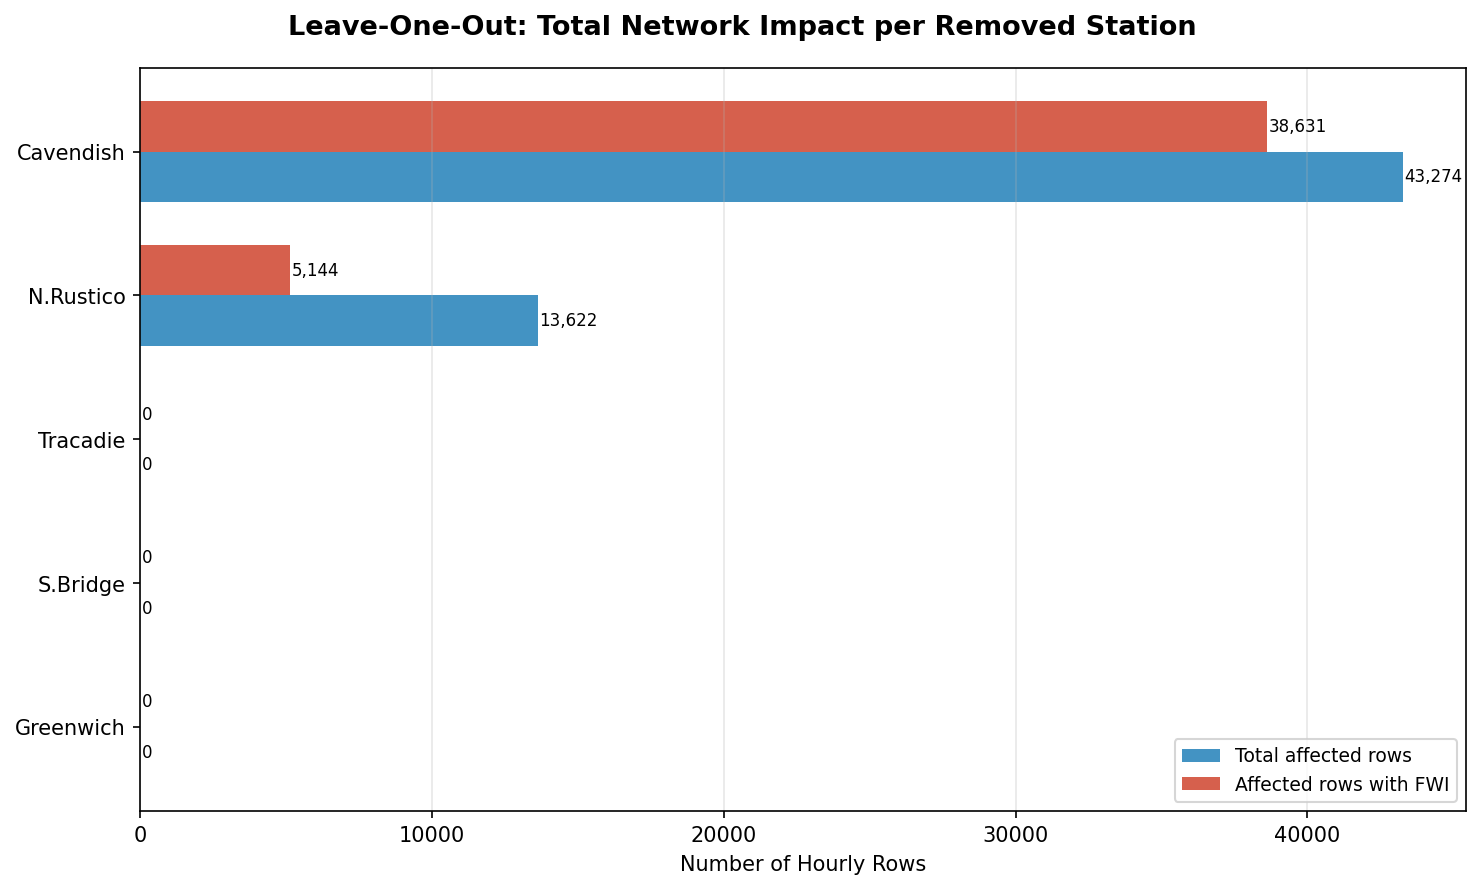

| Station removed | Rows affected elsewhere | Rows with FWI affected | Max MAE on a downstream station |
|---|---|---|---|
| **Cavendish** | **43,274** | **38,631** | 3.57 FWI points (Tracadie) |
| North Rustico | 13,622 | 5,144 | 7.72 (Greenwich; tiny n) |
| Greenwich | 0 | 0 | — |
| Stanhope | 0 | 0 | — |
| Stanley Bridge | 0 | 0 | — |
| Tracadie | 0 | 0 | — |

**Cavendish is the network's largest single donor.** Removing it would shift 38,631 downstream hourly FWI values by up to 3.57 FWI points — material for fire-weather decisions. North Rustico is a secondary donor (13,622 rows). Stanley Bridge, Tracadie, and Greenwich donate nothing to the rest of the network — removing any of the three has zero LOO impact on the other stations.

### Partial correlation: which agreement is "real"?

When two PEI stations both correlate strongly with the same regional weather, they will correlate strongly with each other regardless of whether they sit on the same fire ground. Partial correlation controlling for Stanhope removes that shared-airmass effect. The result on air temperature:

- Cavendish ↔ North Rustico: marginal r = 0.994 → partial r = **0.914** (only 8% regional)
- Cavendish ↔ Tracadie: 0.994 → **0.897** (10% regional)
- North Rustico ↔ Tracadie: 0.995 → **0.915** (8% regional)

These three are genuinely locally similar.

- Greenwich ↔ everything else: marginal 0.90–0.94 → partial **0.26–0.41** (55%–71% regional)

**Greenwich's apparent agreement with the rest of the network was almost entirely shared regional weather, not local similarity.** It is the most uniquely-sited station in the array.

- Precipitation: regional dependence 1.4%–7.9% across all pairs.

Rain is essentially independent station-to-station — no station provides redundant precipitation data.

### Extreme-event correlation

Stations agree on calm days; the question is whether they agree when conditions are dangerous. Restricting the correlation calculation to the 95th/99th percentile rows (or fire-weather days, FWI ≥ 15 or ≥ 25) shows substantial degradation:

| Variable | Drop in Pearson r when restricted to extremes |
|---|---|
| Air temperature (99th pct) | ~1.07 |
| Relative humidity (99th pct) | ~1.01 |
| Wind speed (99th pct) | ~0.93 |
| **FWI (FWI ≥ 25 days)** | **~1.14** |

The 96% temperature redundancy is dominated by the ~90% of "normal" hours. On the ~10% of hours that matter for fire decisions, stations disagree much more.

### Recommendation (carried into §7.4)

| Station | Recommendation |
|---|---|
| **Stanhope** | Keep |
| **Cavendish** | Keep |
| **Greenwich** | Keep |
| **North Rustico** | Defer |
| **Stanley Bridge** | Defer |
| **Tracadie** | Defer |

**No station passes the bar for confident decommissioning.** The only operationally plausible candidates are Stanley Bridge and Tracadie (zero network-donor role, already mostly-synthetic RH). Even those decisions should weigh (i) the loss of the small share of real RH observations they currently produce, and (ii) the resulting increase in imputation load on the remaining stations.


## 6. Uncertainty Quantification

Risk probabilities and confidence intervals for station removal.

> **What this section is for (non-technical).** For each station, we estimate the probability that removing it would meaningfully degrade the network's coverage. The probability is computed from how often that station diverges from the Stanhope reference; the 95% confidence interval captures how much sample noise affects that estimate. **This metric is built from temperature divergence only** — the recommendation in §5 and §7.4 incorporates the multivariate and LOO evidence as well.
>
> **Finding.** All five non-reference stations fall in the **low risk band** by this temperature-divergence metric (3%–13%). Greenwich scores lowest (3%), but the PCA, the cluster distance matrix, and the partial-correlation analysis in the [Extended Redundancy Report](redundancy_extended.html) all flag Greenwich as the most uniquely-sited station in the network. The recommendation in §5 and §7.4 keeps Greenwich on that basis.


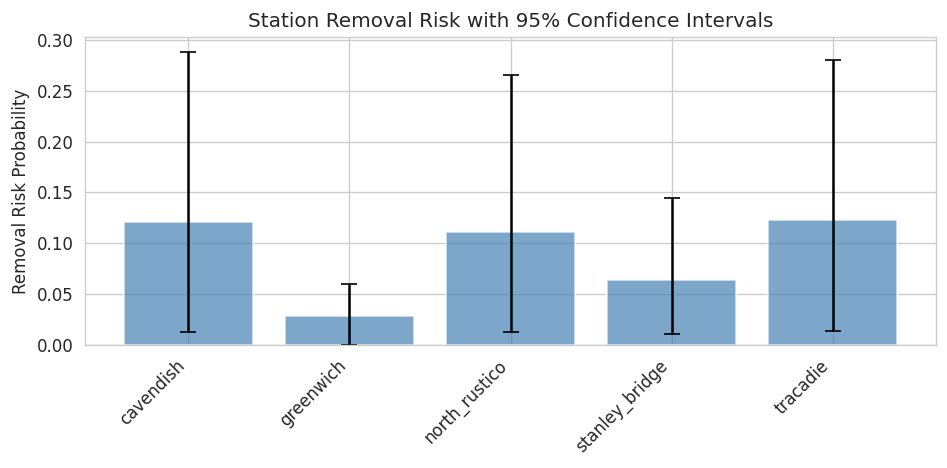

In [29]:
# Rebuild the inputs the temperature-divergence risk needs. The earlier
# temperature-only PCA/clustering cells were removed in the consolidation;
# the small recompute below keeps §6 standalone.
temp_frames = []
for station in stations:
    fpath = PROCESSED_DIR / station / "station_hourly.csv"
    df = pd.read_csv(fpath, parse_dates=["timestamp_utc"])
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = df[df["timestamp_utc"] >= ANALYSIS_START]
    if "air_temperature_c" in df.columns:
        temp_frames.append(df[["station", "timestamp_utc", "air_temperature_c"]])
temp_all = pd.concat(temp_frames, ignore_index=True)
matrix = build_station_matrix(temp_all, value_column="air_temperature_c")
try:
    benchmark = benchmark_to_stanhope(matrix, reference_station="stanhope")
except ValueError:
    benchmark = None

from pea_met_network.uncertainty import quantify_station_removal_risk

if benchmark is not None and len(benchmark) > 0:
    uncertainty = quantify_station_removal_risk(benchmark)
    print("Uncertainty Quantification (KDE-based risk):")
    print(uncertainty.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    stations_plot = uncertainty["station"].tolist()
    risks = uncertainty["risk_probability"].tolist()
    ci_lo = uncertainty["ci_lower"].tolist()
    ci_hi = uncertainty["ci_upper"].tolist()

    x = range(len(stations_plot))
    ax.bar(x, risks, color="steelblue", alpha=0.7)
    yerr_lo = [r - lo for r, lo in zip(risks, ci_lo)]
    yerr_hi = [hi - r for r, hi in zip(risks, ci_hi)]
    ax.errorbar(x, risks, yerr=[yerr_lo, yerr_hi], fmt="none", c="black", capsize=5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(stations_plot, rotation=45, ha="right")
    ax.set_ylabel("Removal Risk Probability")
    ax.set_title("Station Removal Risk with 95% Confidence Intervals")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "uncertainty_risk.png", bbox_inches="tight")
else:
    print("Uncertainty analysis requires benchmark data (skipped).")


# 7. Conclusion

### 7.1 Network status

Six stations operated across the analysis window (**2023-04-01 → 2026-03-23**, with Stanhope ending 2025-12-31 and Tracadie starting 2023-06-29). Hourly completeness for the four FWI core inputs (temperature, RH, wind, rain) ranged from **99.7%** at Stanhope to **~82%** at Stanley Bridge and Tracadie before imputation. After the pipeline's quality enforcement, in-time imputation, and cross-station fill, the FWI chain is computable for every station on every analysis day.

### 7.2 Data-quality caveats

- **Relative humidity is the dominant gap.** It accounts for the majority of FWI chain breaks (62 of 143 are RH-only, with another 47 involving RH plus other inputs).
- **Stanley Bridge and Tracadie RH is almost entirely synthesised.** ~72% of Stanley Bridge RH and ~72% of Tracadie RH is cross-station imputed. FWI values at these two stations should be reported as **network-blended** rather than as independent station observations.
- **Stanhope is the most complete station but is not multi-sensor**: barometric pressure, solar radiation, and wind gust are not measured there (100% missing on those channels). Treat Stanhope as a reliable temperature/RH/wind/rain reference, not as a general-purpose station.
- **Out-of-range counts are zero post-enforcement.** This is the expected state after the pipeline's quality-enforcement pass — not a sign of perfect upstream data.

### 7.3 Redundancy results

- **Temperature** (§5): PC1 explains 96.3% of hourly-temperature variance with effectively equal loadings across all six stations. Pairwise distances between Cavendish, North Rustico, and Tracadie are ≤ 0.006 — they are effectively interchangeable on temperature alone. Benchmark correlations to Stanhope are 0.90 (Greenwich) to 0.97 (Tracadie).
- **RH, wind, and precipitation** (§5 and [Extended Redundancy Report](redundancy_extended.html)): PC1 explains only 79%, 71%, and 55% of variance respectively, and 0 of 60 station pairs cross the 95%-confident-redundant bootstrap threshold on any non-temperature variable.
- **Leave-one-out donor impact** (§5): Cavendish is by far the largest donor in the cross-station imputation network (38,631 downstream FWI rows affected on removal, MAE up to 3.57 FWI points); North Rustico is second (5,144 rows). Greenwich, Stanley Bridge, and Tracadie are net receivers and donate nothing to the rest of the network.
- **Partial correlation controlling for Stanhope** (§5): Greenwich's correlation with every other station collapses from ~0.91 to 0.26–0.41 — its apparent agreement was almost entirely shared regional weather, not local similarity. Cavendish, North Rustico, and Tracadie remain genuinely locally similar (partial r ~0.90).
- **Extreme-event correlation** (§5): cross-station agreement degrades by ~1.0–1.1 in Pearson r when restricted to 95th/99th-percentile conditions or FWI ≥ 25 days — exactly the conditions when the dashboard is most consulted.

### 7.4 Recommendation

| Station | Recommendation | Why |
|---|---|---|
| **Stanhope** | **Keep** | Reference station; lowest missingness; only station with complete observed records for all four FWI core inputs |
| **Cavendish** | **Keep** | Largest single donor in the cross-station imputation network — removal would degrade 38,631 downstream FWI values by up to 3.57 points |
| **Greenwich** | **Keep** | Partial correlation vs Stanhope collapses Greenwich's agreement with every other station from ~0.91 to 0.26–0.41 — it is the most uniquely-sited station in the array |
| **North Rustico** | **Defer** | Second-largest donor (13,622 downstream rows); locally similar to Cavendish and Tracadie on temperature and RH |
| **Stanley Bridge** | **Defer** | Net receiver in the imputation network (zero outgoing donations); RH ~83% synthetic; still produces independent temperature, wind, and a small share of real RH |
| **Tracadie** | **Defer** | Net receiver, RH ~87% synthetic; locally similar to Cavendish/North Rustico on temperature; small share of real RH |

**No station passes the bar for confident decommissioning.** If field-unit operational pressures require a decommission decision regardless, **Stanley Bridge and Tracadie are the only candidates** that survive the multivariate + LOO evidence — both are net receivers and both already have heavily-imputed RH.

### 7.5 Limits of this recommendation

1. **The §7.4 recommendation is conservative.** No station passes the bar for confident decommissioning on the multivariate + LOO evidence. If field-unit operational pressures require a decommission regardless, Stanley Bridge and Tracadie are the only candidates that survive that evidence — both are net receivers in the cross-station imputation network and both already have heavily-imputed RH. Even those decisions should weigh (i) the loss of the small share of real RH observations the station produces, and (ii) the resulting increase in imputation load on the remaining stations.
2. **Pre-removal donor check needed.** If Stanley Bridge or Tracadie is decommissioned, the cross-station imputer will lean harder on the remaining stations — particularly Cavendish, which is already the largest donor. A donor-impact simulation should run before any removal is acted on.
3. **Reference window asymmetry.** The Stanhope reference ends 2025-12-31; the partial-correlation and benchmark scores omit the most recent ~3 months of data from the comparison stations.
4. **Extreme-event correlation matters more than full-record correlation.** The §7.4 recommendation favours retention partly because cross-station agreement degrades on fire-weather days — exactly when the dashboard is consulted. This argument is independent of imputation-network role and should not be relaxed if a decommission decision is later revisited.

### 7.6 Next steps

1. Field validation of the *defer* candidates (North Rustico, Stanley Bridge, Tracadie) against operational fire-behaviour needs (access, response time, dual-use sensors, RH sensor rehabilitation).
2. **If any station is decommissioned**, re-run §5 with that station removed from the donor set before deploying — confirm the remaining stations can carry the imputation load.
3. If the dashboard is hosted for live updates, add an automated alert when any station's daily FWI inputs cross from `qf == 1` to `qf == 9` for two consecutive days.
4. Backfill or rehabilitate the RH sensors at Stanley Bridge and Tracadie — they are the network's single largest data-quality risk to FWI accuracy and the primary reason the recommendation defers (rather than removes) these stations.
